## MONAI imports

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
import json
import argparse
import numpy as np
import os
from pathlib import Path
import torch.nn.functional as F
from mpl_toolkits.axes_grid1 import make_axes_locatable
import glob
# Import project-specific modules
from monai.utils import set_determinism
from utils_main import *
from utils_criteria import *
from utils_GANSim import *
# Set random seed for reproducibility
set_determinism(42)

# Load configuration files
with open(r"E:\Code\monai\ldm_2d_geomodel\configs\environment.json", "r") as f:
    env = json.load(f)
with open(r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f4_c64_r1.json", "r") as f:
    cfg = json.load(f)
args = argparse.Namespace(**env, **cfg)
rank = 0;world_size = 1
args.imgs_dir = r"E:\Code\monai\ldm_2d_geomodel\data"
train_loader, val_loader, test_loader = prepare_conditional_geomodel_dataset(args,augmentation_level = 0, condition_level = 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Train images shape: torch.Size([2672, 1, 64, 64]), Train prob maps shape: torch.Size([2672, 1, 64, 64]), Train well facies shape: torch.Size([2672, 4, 64, 64])
Validation images shape: torch.Size([800, 1, 64, 64]), Validation prob maps shape: torch.Size([800, 1, 64, 64]), Validation well facies shape: torch.Size([800, 4, 64, 64])
Test images shape: torch.Size([400, 1, 64, 64]), Test prob maps shape: torch.Size([400, 1, 64, 64]), Test well facies shape: torch.Size([400, 4, 64, 64])
Using device: cuda


## Visualize the first batch of images

In [2]:
first_batch = next(iter(train_loader))
first_val_batch = next(iter(val_loader))
print(f"First batch shape: {first_batch[0].shape}, with {len(train_loader)} batches in train_loader")
print(f"First validation batch shape: {first_val_batch[0].shape}, with {len(val_loader)} batches in val_loader")

First batch shape: torch.Size([16, 1, 64, 64]), with 167 batches in train_loader
First validation batch shape: torch.Size([16, 1, 64, 64]), with 50 batches in val_loader


Batch 3:
  Images shape: torch.Size([16, 1, 64, 64])
  Probability realizations shape: torch.Size([16, 1, 64, 64])
  Well facies shape: torch.Size([16, 4, 64, 64])


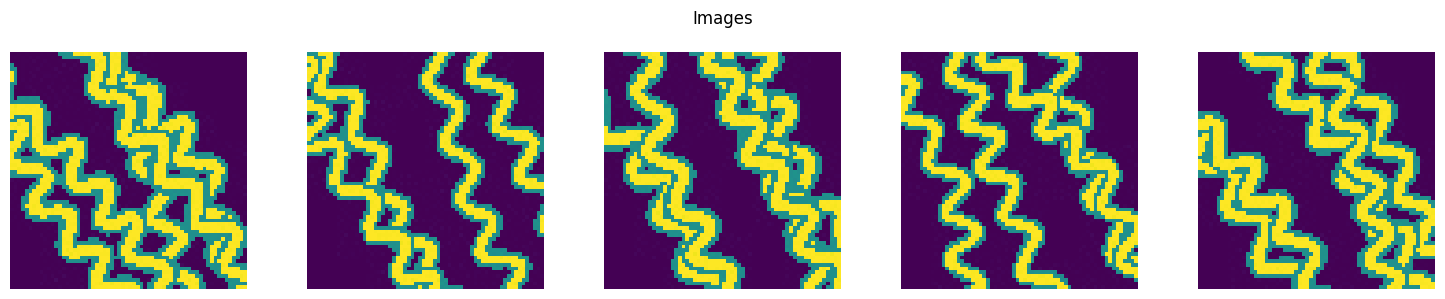

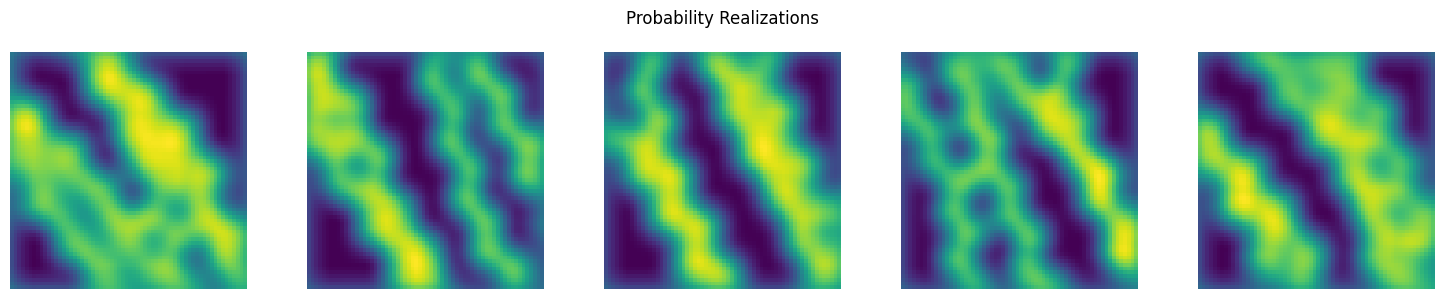

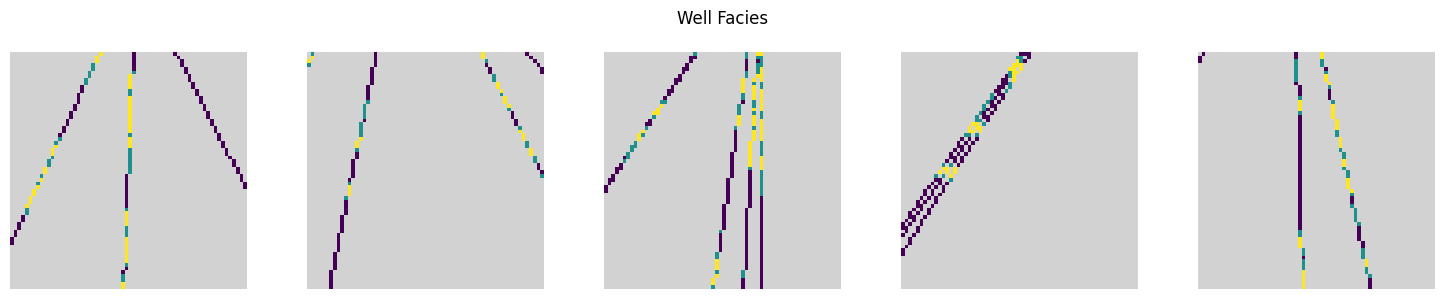

In [3]:
for i, (images, prob_rlzs, well_facies) in enumerate(train_loader):
    if i == 2:
        print(f"Batch {i+1}:")
        print(f"  Images shape: {images.shape}")
        print(f"  Probability realizations shape: {prob_rlzs.shape}")
        print(f"  Well facies shape: {well_facies.shape}")
        break
n_plt = 5
random_indicies = torch.randperm(images.shape[0])[:n_plt]
show_grid(images[random_indicies], n_cols= n_plt, n_samples = n_plt, title= "Images")
show_grid(prob_rlzs[random_indicies], n_cols= n_plt, n_samples = n_plt, title= "Probability Realizations")

n_facies = 3
viridis = plt.get_cmap('viridis', 256)
colors = viridis(np.linspace(0, 1, n_facies))
# Add a contrasting color for the background
colors = np.vstack((colors[:, :3], [0.827, 0.827, 0.827]))  # Light grey
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(colors)

show_grid(torch.argmax(well_facies[random_indicies],1).unsqueeze(1), n_cols= n_plt, n_samples = n_plt, title= "Well Facies", cmap=custom_cmap, interpolation='nearest', vmin=0, vmax=n_facies)

## Load and visualize VAE models on train/val/test sets

In [4]:
# Define model paths and names
model_paths = [
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\guido_f8_original_vae_epoch_hd0_best.pt", # Guido F8 Original
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\guido_f8_z4_vae_epoch_hd0_best.pt", # Guido F8 Z4
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\tune_f8_vae_epoch_hd0_best.pt", # Tuned F8  
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\tuned_f4_vae_epoch_hd0_best.pt", # Tuned F4
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\SD_f8_c128_r2_vae_epoch_hd0_best.pt", # SD F8 C128 R2
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\SD_f8_c64_r2_vae_epoch_hd0_best.pt", # SD F8 C64 R2
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\SD_f8_c64_r1_vae_epoch_hd0_best.pt", # SD F8 C64 R1
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\SD_f4_vae_epoch_hd0_best.pt", # SD F4 C128 R2
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\SD_f4_c64_r1_vae_epoch_hd0_best.pt", # SD F4 C64 R1
    r"E:\Code\monai\ldm_2d_geomodel\trained_vae\SD_f4_c64_r2_vae_epoch_hd0_best.pt" # SD F4 C64 R2
    ]
print(f"Found {len(model_paths)} model files")

# Extract model names from filenames, or assign custom names
model_names = [
                "Guido F8 Original",
                "Guido F8 Z4",
                "Tuned F8",
                "Tuned F4",
                "SD F8 C128 R2",
                "SD F8 C64 R2",
                "SD F8 C64 R1",
                "SD F4 C128 R2",
                "SD F4 C64 R1",
                "SD F4 C64 R2"
               ]
# Load the autoencoder models
# Replace your model‐loading cell with the LDM AutoencoderKL and non‐strict load:
config_paths = [r"E:\Code\monai\ldm_2d_geomodel\configs\guido_f8_original.json", # Guido F8 Original
                r"E:\Code\monai\ldm_2d_geomodel\configs\guido_f8_z4.json", # Guido F8 Z4
                r"E:\Code\monai\ldm_2d_geomodel\configs\tuned_f8.json", # Tuned F8
                r"E:\Code\monai\ldm_2d_geomodel\configs\tuned_f4.json", # Tuned F4
                r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f8_c128_r2.json", # SD F8 C128 R2
                r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f8_c64_r2.json", # SD F8 C64 R2
                r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f8_c64_r1.json", # SD F8 C64 R1
                r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f4_c128_r2.json", # SD F4 C128 R2
                r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f4_c64_r1.json", # SD F4 C64 R1
                r"E:\Code\monai\ldm_2d_geomodel\configs\SD_f4_c64_r2.json" # SD F4 C64 R2
                ]

autoencoders = []
for i,(model_path,config_path) in enumerate(zip(model_paths,config_paths)):
    # Load configuration files
    with open(config_path, "r") as f:
        cfg = json.load(f)
    args = argparse.Namespace(**env, **cfg)    
    # instantiate the same VAE class used during training
    ae = define_instance(args, "autoencoder_def").to(device)
    
    # load checkpoint with strict=False to allow mismatched keys
    ckpt = torch.load(model_path, map_location=device)
    if "model" in ckpt:
        ae.load_state_dict(ckpt["model"], strict=False)
    else:
        # Fallback for checkpoints that might just be the state_dict
        ae.load_state_dict(ckpt, strict=False)

    ae.eval()
    autoencoders.append(ae)

print(f"Loaded {len(autoencoders)} models")

Found 10 model files


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Loaded 10 models


# Evaluate on validation set

In [5]:
# Generate reconstructions from each model
# Initialize lists to store results for each model
all_reconstructions = [[] for _ in autoencoders]
all_mae_scores = [[] for _ in autoencoders]
all_rel_errors = [[] for _ in autoencoders]
original_images = []

# Iterate over the validation loader
for (batch,_,_) in val_loader:
    val_batch = batch.to(device)
    original_images.append(val_batch.cpu())

    # Iterate over each model
    for i, model in enumerate(autoencoders):
        with torch.no_grad():
            reconstruction, _, _ = model(val_batch)
        
        all_reconstructions[i].append(reconstruction.cpu())

        # Calculate metrics for the current batch
        mae = F.l1_loss(reconstruction, val_batch).item()
        all_mae_scores[i].append(mae)

        # Calculate relative error on non-zero pixels
        non_zero_mask = val_batch != 0
        if non_zero_mask.sum() > 0:
            rel_error_vals = torch.abs(reconstruction - val_batch)[non_zero_mask] / torch.abs(val_batch[non_zero_mask] + 1e-8)
            rel_error = rel_error_vals.mean().item()
        else:
            rel_error = float('inf')
        all_rel_errors[i].append(rel_error)

# Concatenate all batches to get the full dataset results
# all_reconstructions will be a list of tensors, one for each model
# each tensor will have the shape (800, 1, 64, 64)
all_reconstructions = [torch.cat(recon_batches) for recon_batches in all_reconstructions]
original_images = torch.cat(original_images)

# all_mae_scores and all_rel_errors will be lists of lists, 
# which can be converted to numpy arrays for easier analysis.
mae_scores_np = [np.array(scores) for scores in all_mae_scores]
rel_errors_np = [np.array(errors) for errors in all_rel_errors]

# Example of how to access the results:
# Reconstructions from the first model: all_reconstructions[0]
# MAE scores for the first model: mae_scores_np[0]
print(f"Shape of reconstructions for model 1: {all_reconstructions[0].shape}")
print(f"Shape of original images: {original_images.shape}")
print(f"Number of MAE scores for model 1: {len(mae_scores_np[0])}")
print(f"Length of all_reconstructions: {len(all_reconstructions)}")

Shape of reconstructions for model 1: torch.Size([800, 1, 64, 64])
Shape of original images: torch.Size([800, 1, 64, 64])
Number of MAE scores for model 1: 50
Length of all_reconstructions: 10


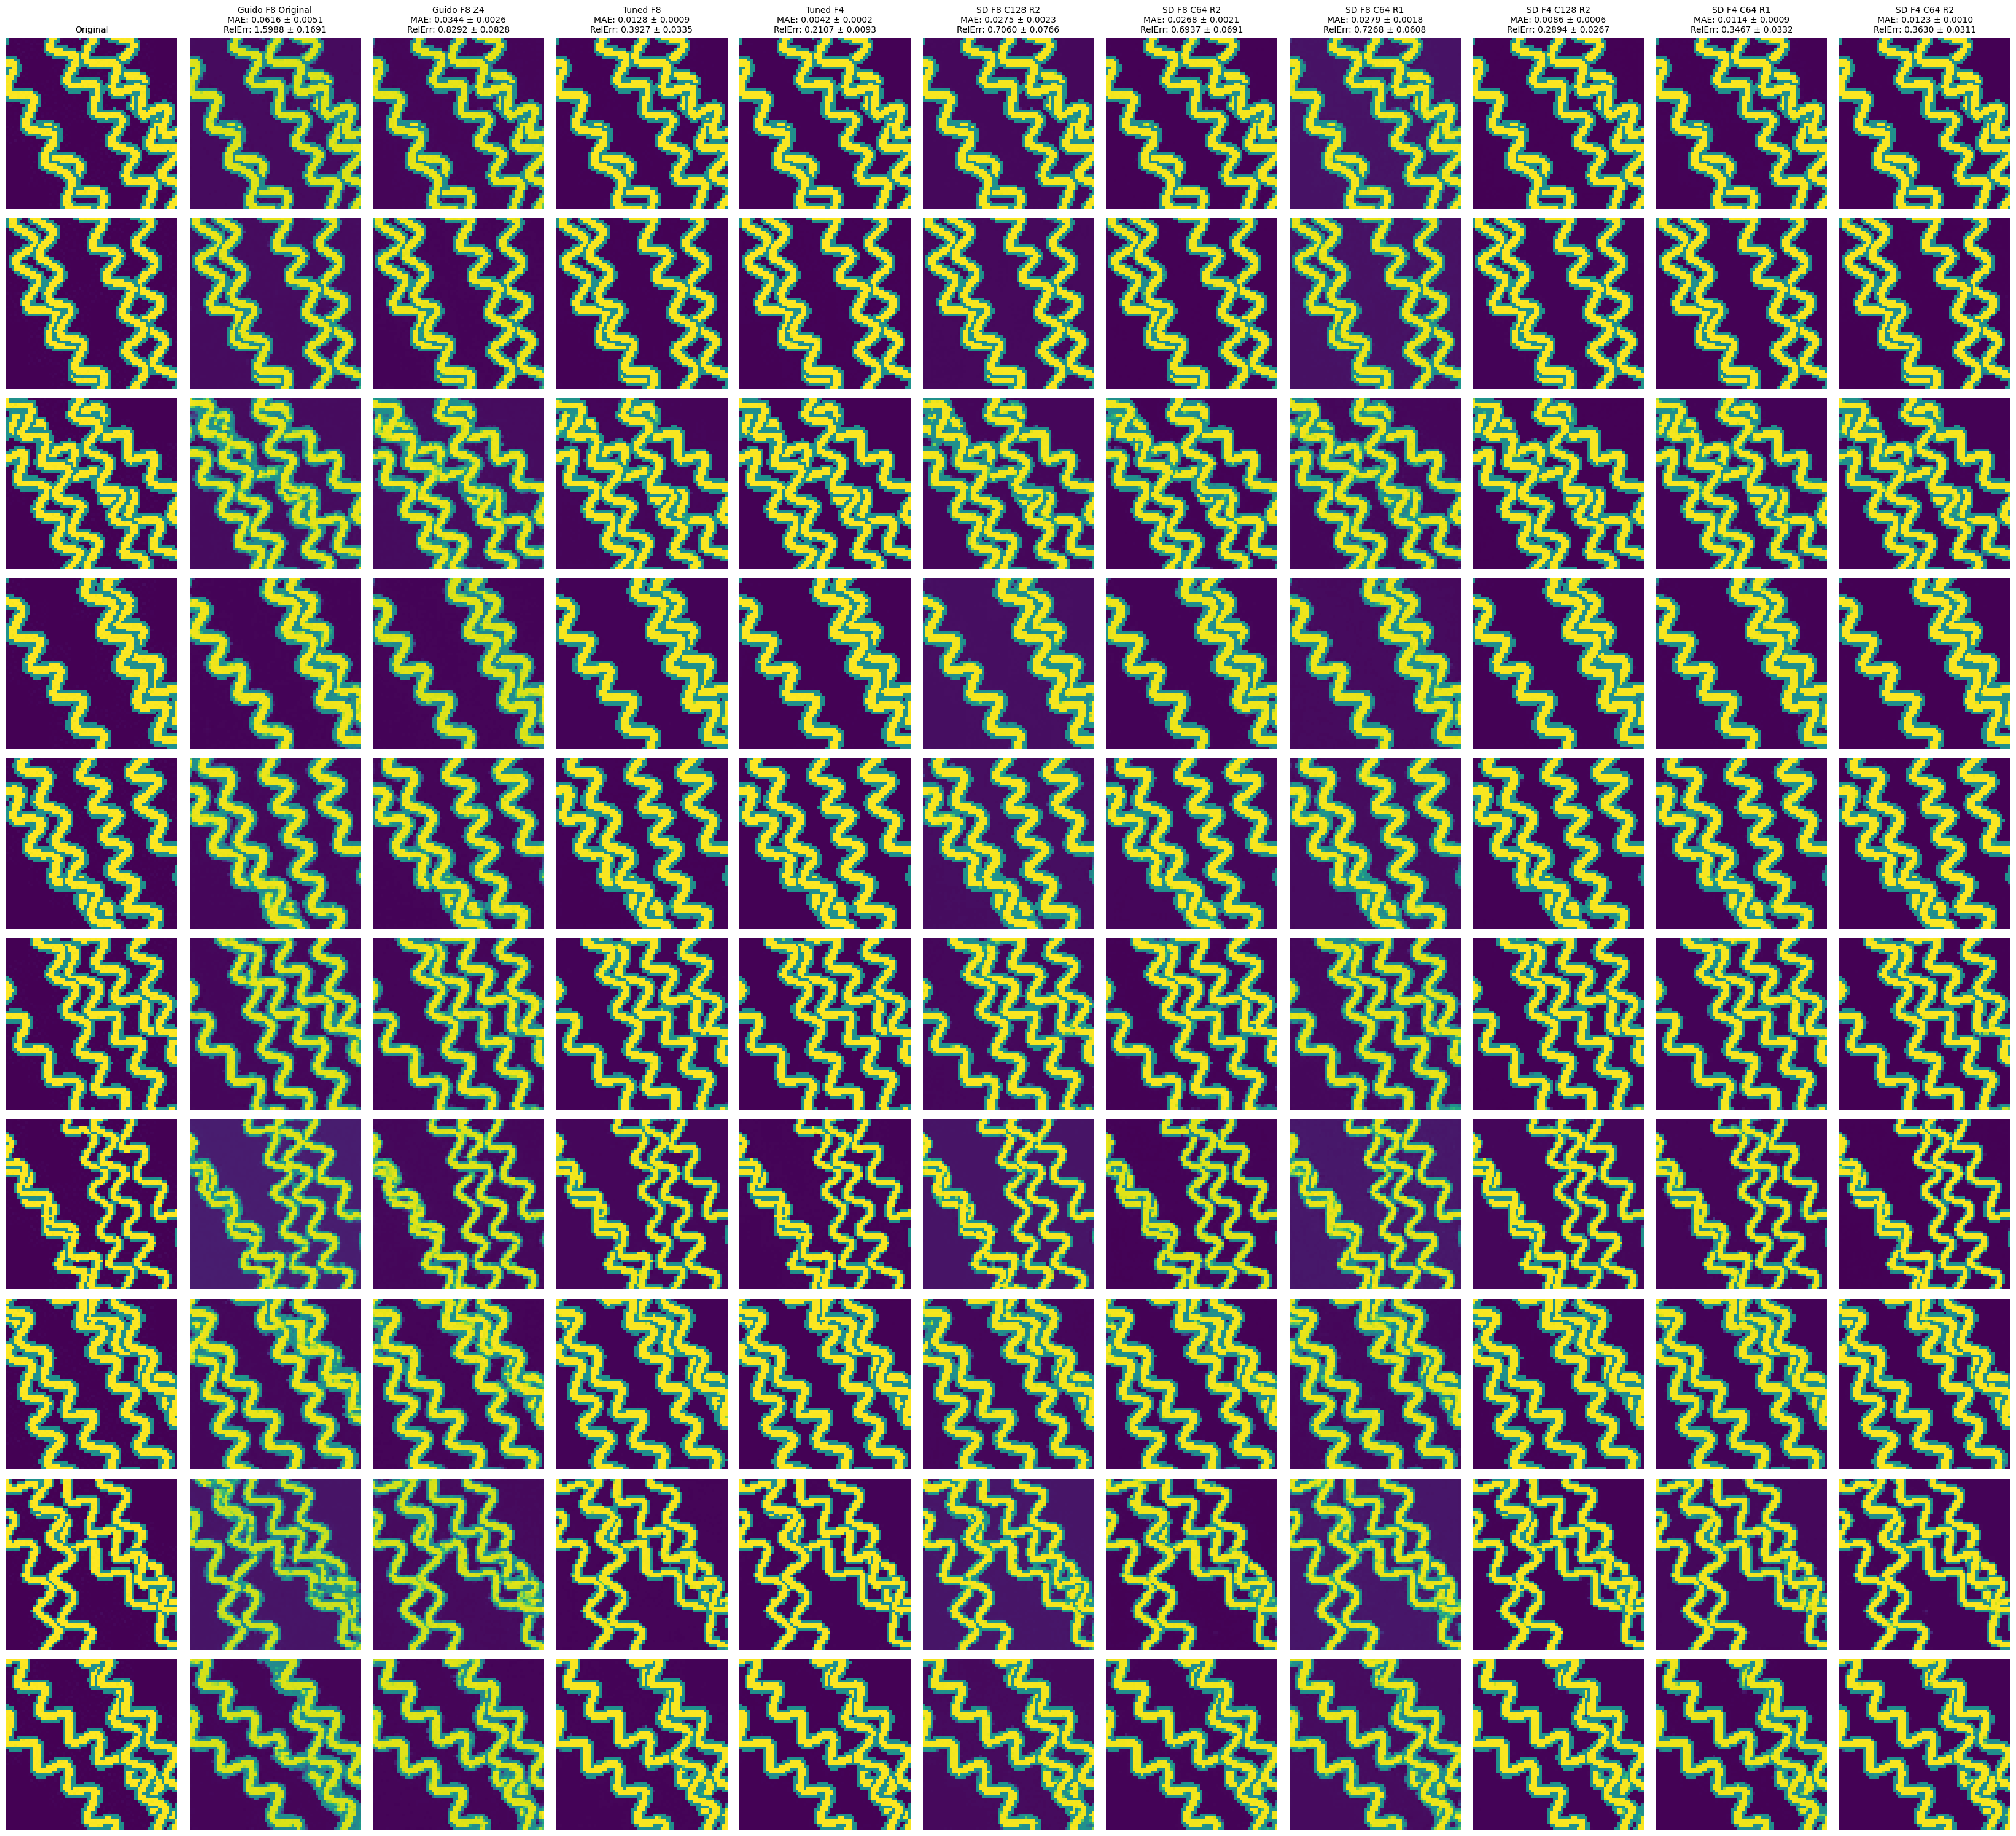

In [6]:
num_samples = 10 # Or any number of samples you want to visualize
num_models = len(autoencoders)

# Get random indices from the validation set
total_images = len(original_images)
random_indices = np.random.choice(total_images, num_samples, replace=False)

# Create the plot
fig, axes = plt.subplots(num_samples, 1 + num_models,
                         figsize=(3 * (1 + num_models), 3 * num_samples),
                         squeeze=False)

# Set column titles
col_titles = (
    ["Original"]
    + [f"{model_names[i]}\nMAE: {np.mean(mae_scores_np[i]):.4f} ± {np.std(mae_scores_np[i]):.4f}\n"
       f"RelErr: {np.mean(rel_errors_np[i]):.4f} ± {np.std(rel_errors_np[i]):.4f}"
       for i in range(num_models)]
)
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=10)

# Plot each row: original | recon_1 | … | recon_n
for i, idx in enumerate(random_indices):
    # Plot original image
    axes[i, 0].imshow(original_images[idx].squeeze())
    axes[i, 0].axis("off")

    # Plot reconstructions for each model
    for j in range(num_models):
        axes[i, j + 1].imshow(all_reconstructions[j][idx].squeeze())
        axes[i, j + 1].axis("off")

plt.tight_layout()
plt.show()

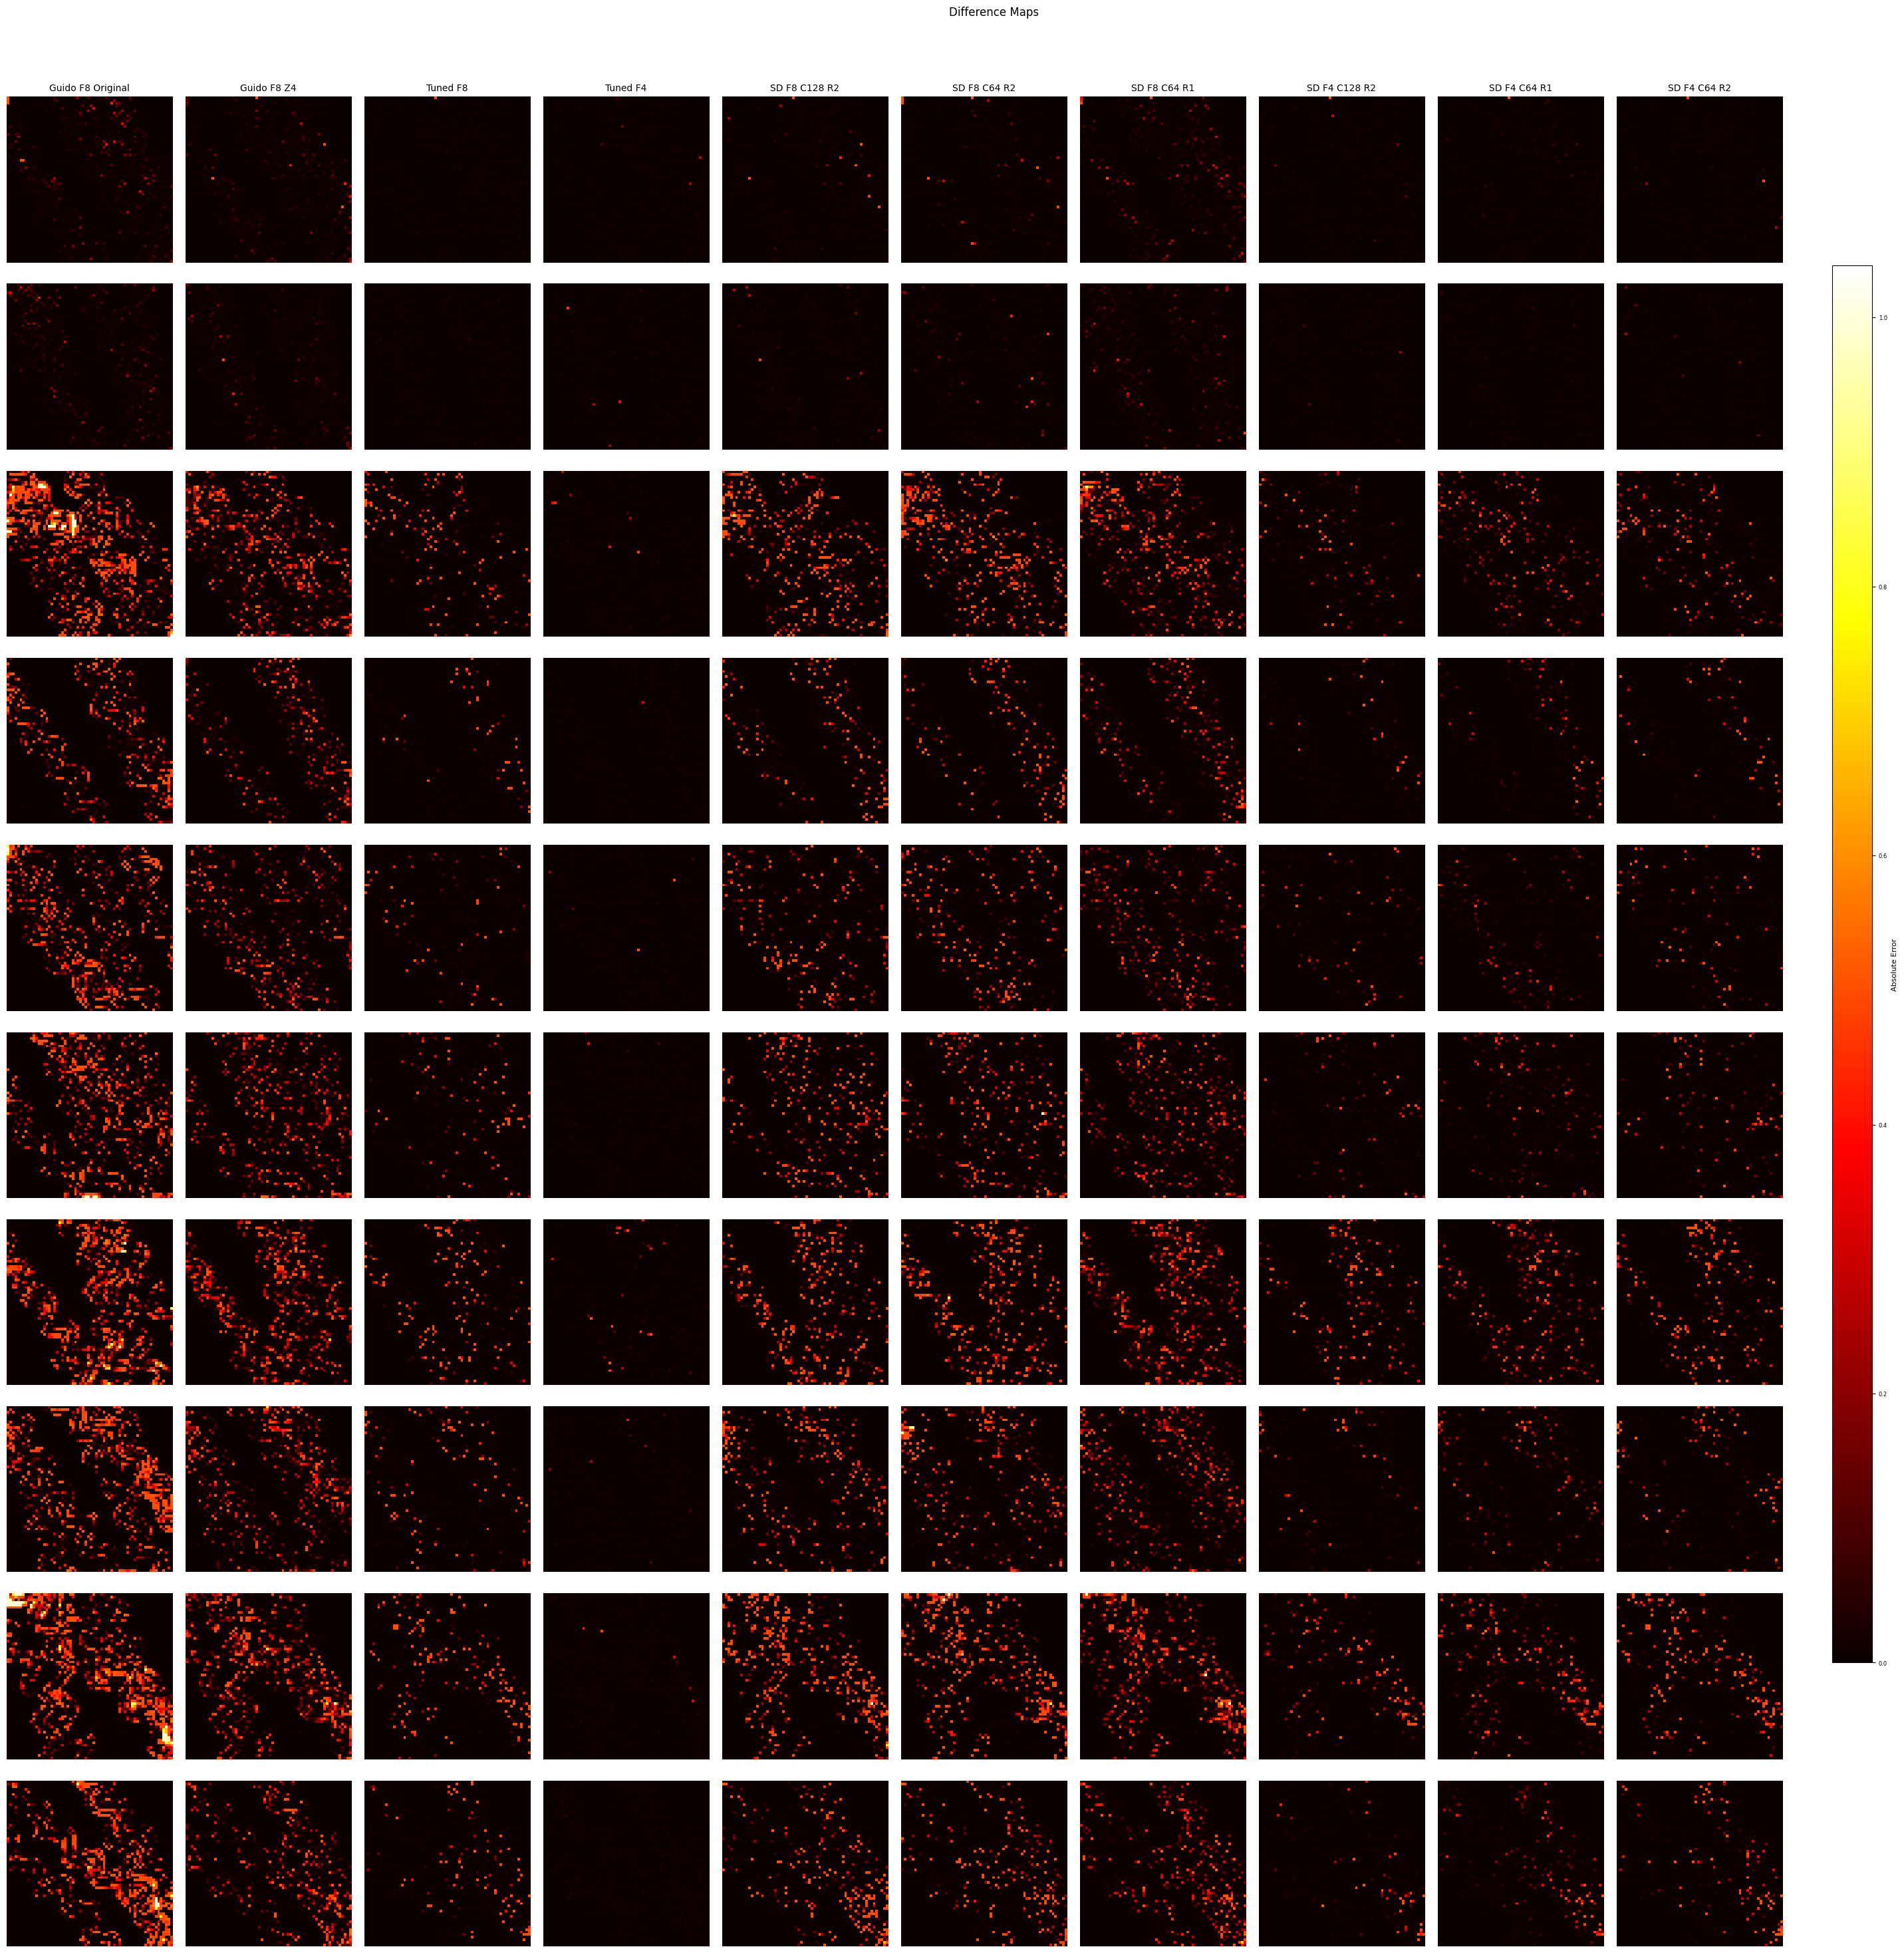

In [7]:
fig, axes = plt.subplots(num_samples, num_models,
                         figsize=(3 * num_models, 3 * num_samples),
                         squeeze=False)
fig.suptitle("Difference Maps", fontsize=12)

# Find the maximum difference for consistent color scaling
max_diff = 0
for idx in random_indices:
    for j in range(num_models):
        diff = torch.abs(all_reconstructions[j][idx] - original_images[idx])
        if diff.max() > max_diff:
            max_diff = diff.max()

# Plot the difference maps for the same random indices
for i, idx in enumerate(random_indices):
    for j in range(num_models):
        diff = torch.abs(all_reconstructions[j][idx] - original_images[idx])
        im = axes[i, j].imshow(diff.squeeze(), cmap="hot", vmin=0, vmax=max_diff)
        axes[i, j].axis("off")

# Set titles for each column with the model name
for j, title in enumerate(model_names):
    axes[0, j].set_title(title, fontsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 0.96], w_pad=1.5) 
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cb.set_label("Absolute Error", fontsize=8)
cb.ax.tick_params(labelsize=6)
plt.show()

### Evaluate on test set

In [8]:
# Generate reconstructions from each model for the test set
# Initialize lists to store results for each model
all_reconstructions_test = [[] for _ in autoencoders]
all_mae_scores_test = [[] for _ in autoencoders]
all_rel_errors_test = [[] for _ in autoencoders]
original_images_test = []

# Iterate over the test loader
for (batch,_,_) in test_loader:
    test_batch = batch.to(device)
    original_images_test.append(test_batch.cpu())

    # Iterate over each model
    for i, model in enumerate(autoencoders):
        with torch.no_grad():
            reconstruction, _, _ = model(test_batch)
        
        all_reconstructions_test[i].append(reconstruction.cpu())

        # Calculate metrics for the current batch
        mae = F.l1_loss(reconstruction, test_batch).item()
        all_mae_scores_test[i].append(mae)

        # Calculate relative error on non-zero pixels
        non_zero_mask = test_batch != 0
        if non_zero_mask.sum() > 0:
            rel_error_vals = torch.abs(reconstruction - test_batch)[non_zero_mask] / torch.abs(test_batch[non_zero_mask] + 1e-8)
            rel_error = rel_error_vals.mean().item()
        else:
            rel_error = float('inf')
        all_rel_errors_test[i].append(rel_error)

# Concatenate all batches to get the full dataset results
all_reconstructions_test = [torch.cat(recon_batches) for recon_batches in all_reconstructions_test]
original_images_test = torch.cat(original_images_test)

# Convert metric lists to numpy arrays for easier analysis.
mae_scores_test_np = [np.array(scores) for scores in all_mae_scores_test]
rel_errors_test_np = [np.array(errors) for errors in all_rel_errors_test]

# Example of how to access the results:
print(f"Shape of reconstructions for model 1 (test): {all_reconstructions_test[0].shape}")
print(f"Shape of original images (test): {original_images_test.shape}")
print(f"Number of MAE scores for model 1 (test): {len(mae_scores_test_np[0])}")


Shape of reconstructions for model 1 (test): torch.Size([400, 1, 64, 64])
Shape of original images (test): torch.Size([400, 1, 64, 64])
Number of MAE scores for model 1 (test): 25


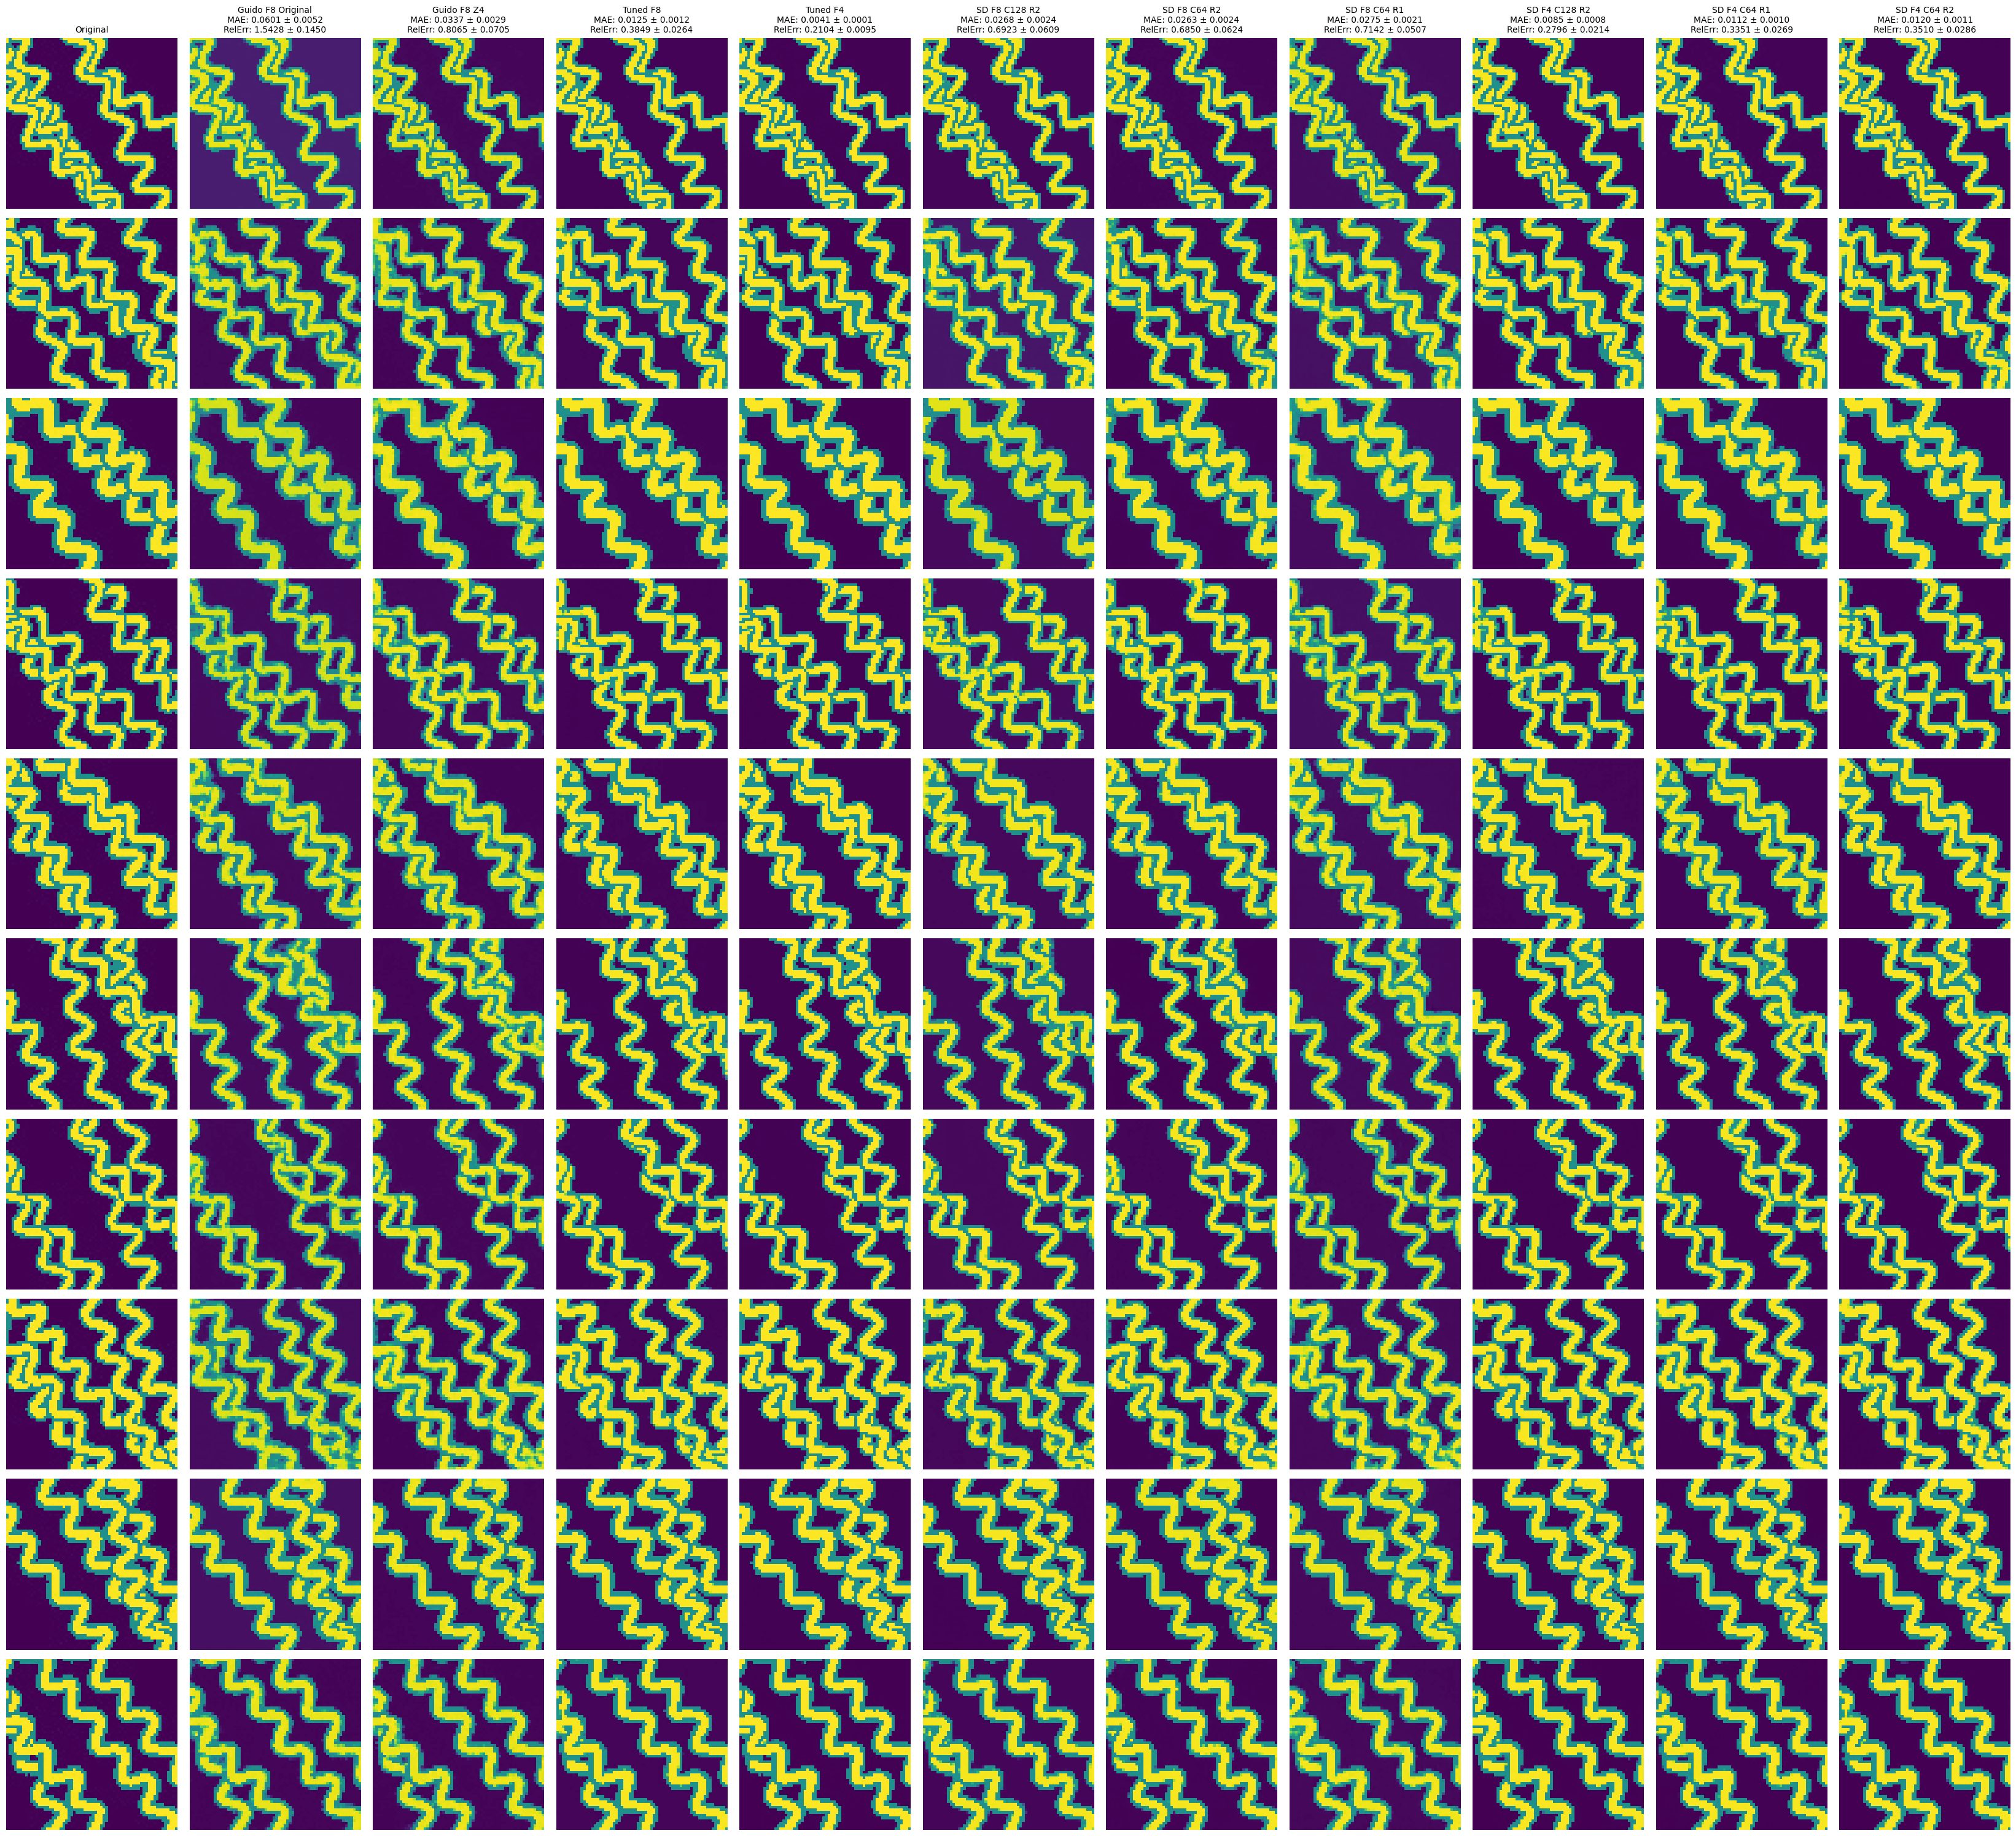

In [9]:
num_samples = 10 # Or any number of samples you want to visualize
num_models = len(autoencoders)

# Get random indices from the validation set
total_images = len(original_images_test)
random_indices = np.random.choice(total_images, num_samples, replace=False)

# Create the plot
fig, axes = plt.subplots(num_samples, 1 + num_models,
                         figsize=(3 * (1 + num_models), 3 * num_samples),
                         squeeze=False)

# Set column titles
col_titles = (
    ["Original"]
    + [f"{model_names[i]}\nMAE: {np.mean(mae_scores_test_np[i]):.4f} ± {np.std(mae_scores_test_np[i]):.4f}\n"
       f"RelErr: {np.mean(rel_errors_test_np[i]):.4f} ± {np.std(rel_errors_test_np[i]):.4f}"
       for i in range(num_models)]
)
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=10)

# Plot each row: original | recon_1 | … | recon_n
for i, idx in enumerate(random_indices):
    # Plot original image
    axes[i, 0].imshow(original_images_test[idx].squeeze())
    axes[i, 0].axis("off")

    # Plot reconstructions for each model
    for j in range(num_models):
        axes[i, j + 1].imshow(all_reconstructions_test[j][idx].squeeze())
        axes[i, j + 1].axis("off")

plt.tight_layout()
plt.show()

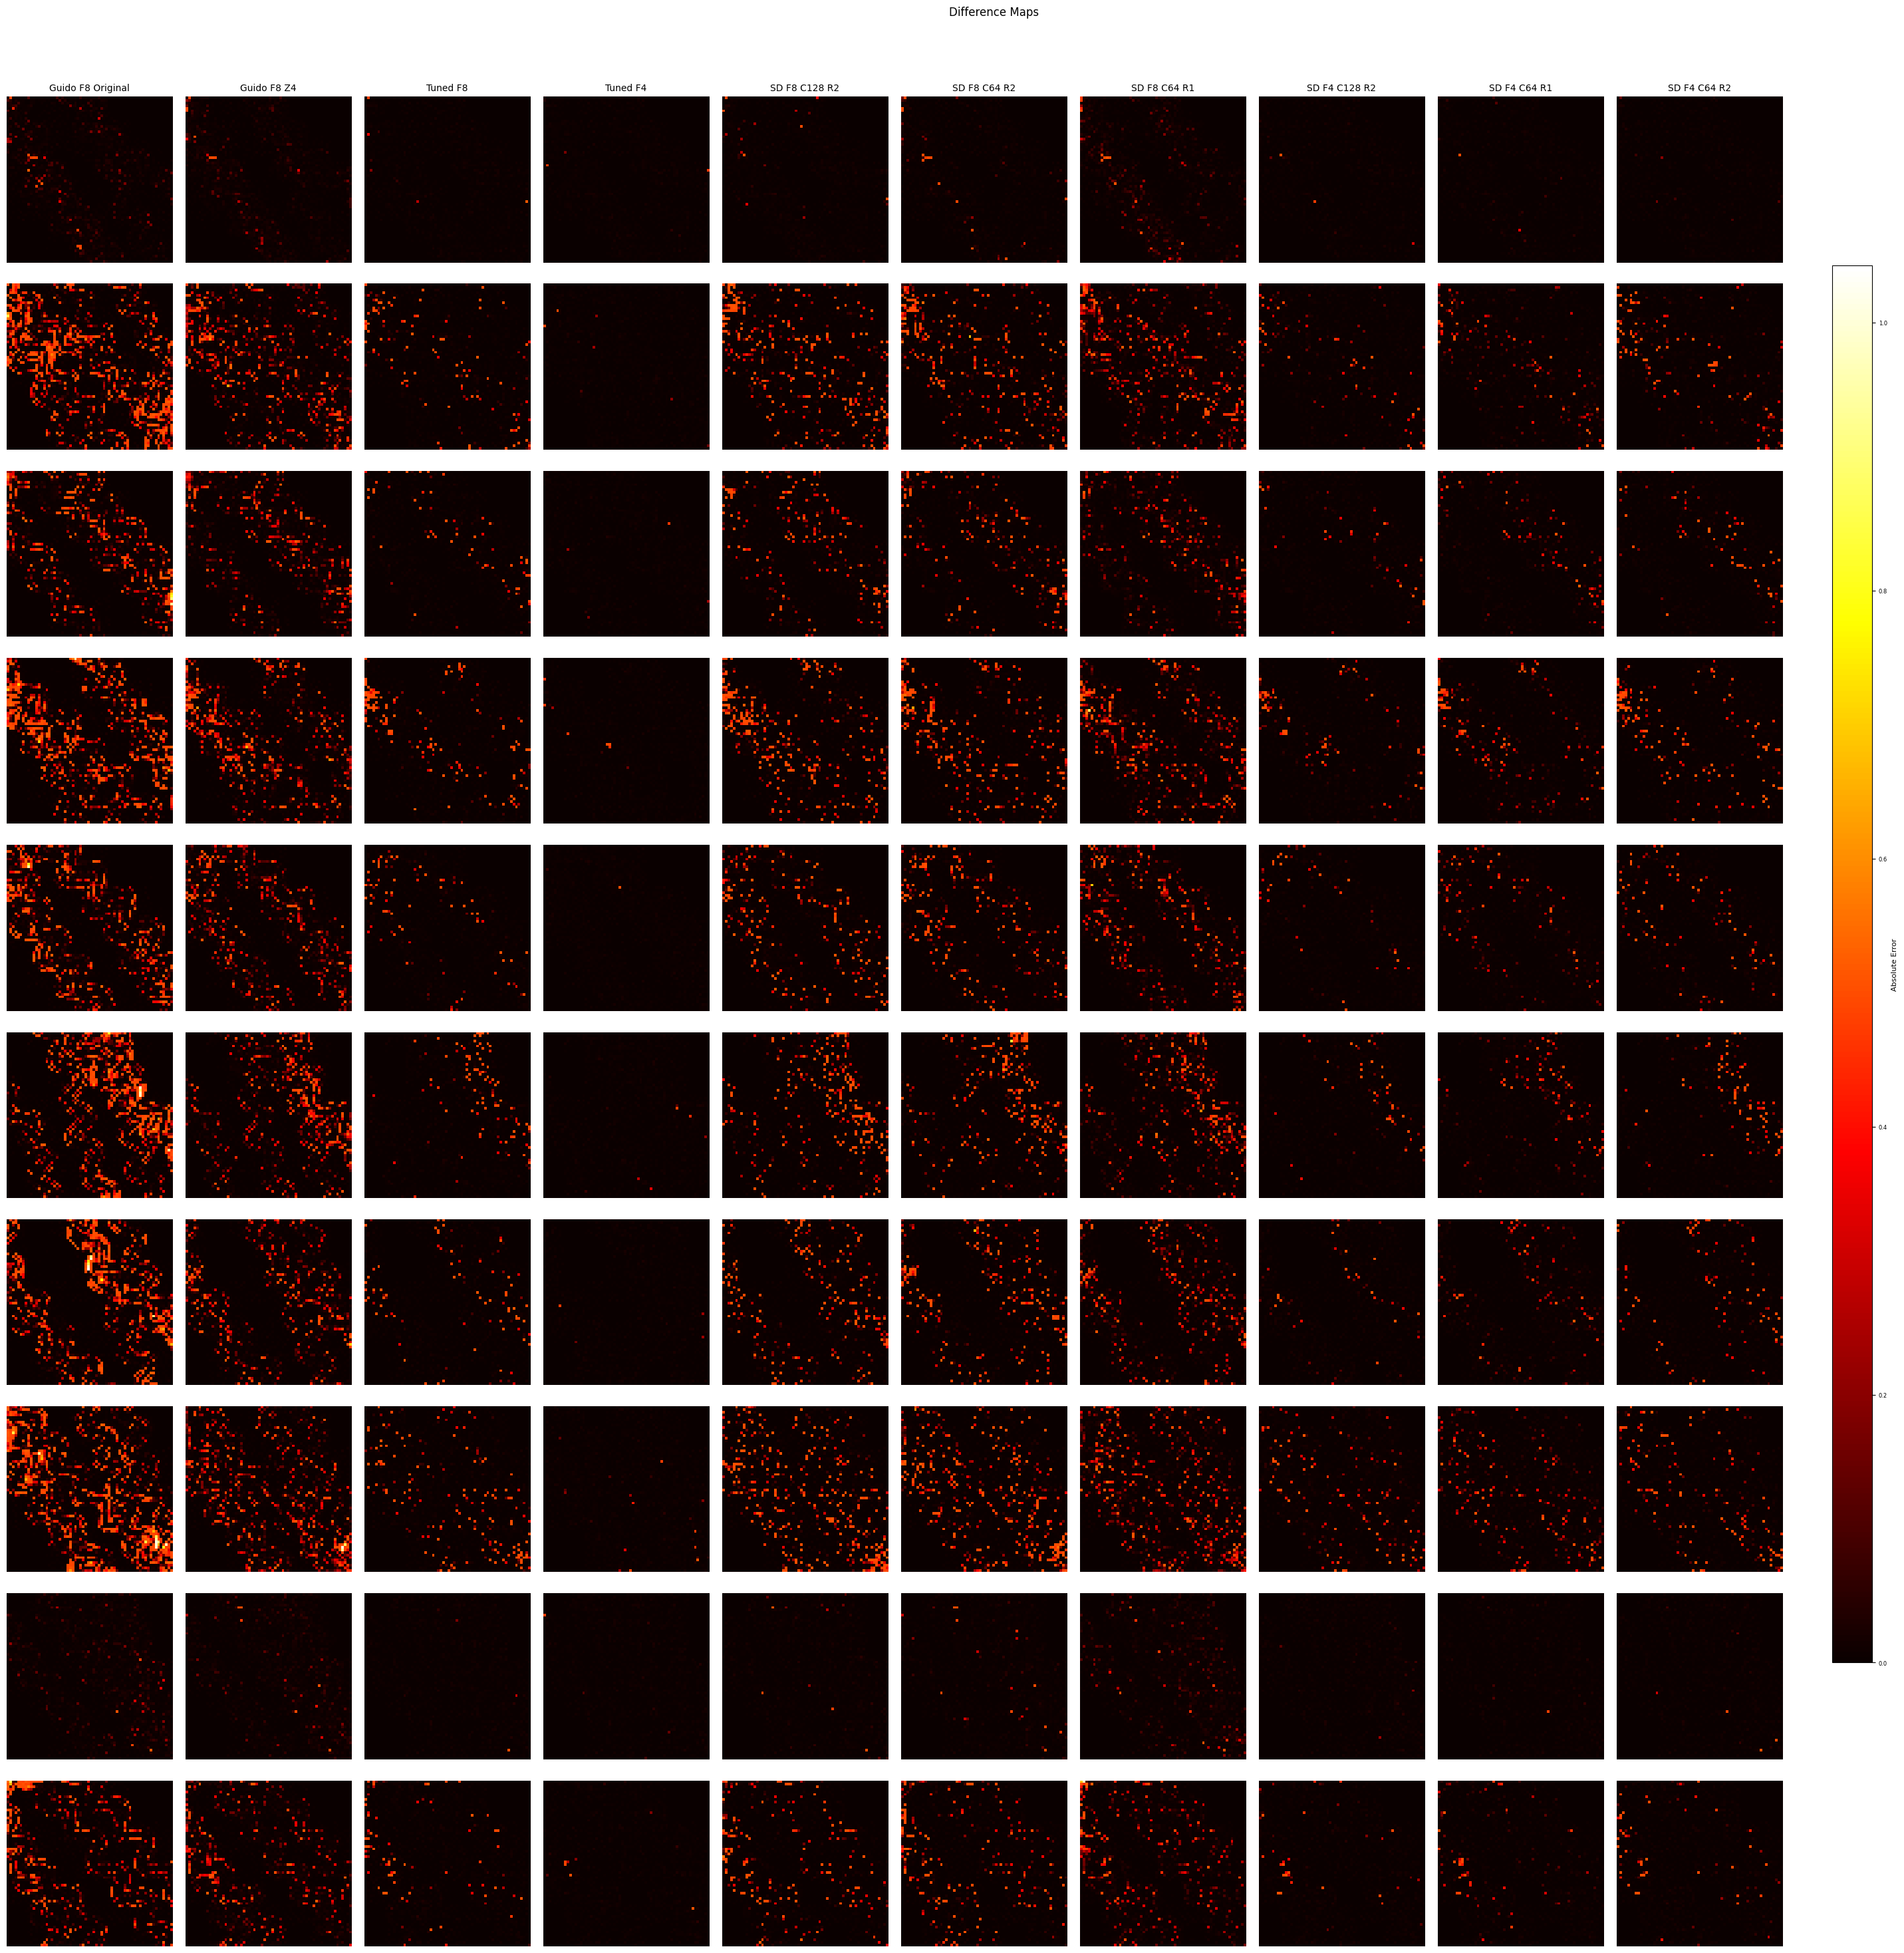

In [10]:
fig, axes = plt.subplots(num_samples, num_models,
                         figsize=(3 * num_models, 3 * num_samples),
                         squeeze=False)
fig.suptitle("Difference Maps", fontsize=12)

# Find the maximum difference for consistent color scaling
max_diff = 0
for idx in random_indices:
    for j in range(num_models):
        diff = torch.abs(all_reconstructions_test[j][idx] - original_images_test[idx])
        if diff.max() > max_diff:
            max_diff = diff.max()

# Plot the difference maps for the same random indices
for i, idx in enumerate(random_indices):
    for j in range(num_models):
        diff = torch.abs(all_reconstructions_test[j][idx] - original_images_test[idx])
        im = axes[i, j].imshow(diff.squeeze(), cmap="hot", vmin=0, vmax=max_diff)
        axes[i, j].axis("off")

# Set titles for each column with the model name
for j, title in enumerate(model_names):
    axes[0, j].set_title(title, fontsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 0.96], w_pad=1.5) 
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cb.set_label("Absolute Error", fontsize=8)
cb.ax.tick_params(labelsize=6)
plt.show()

### Evaluate on train set

In [11]:
# Generate reconstructions from each model for the training set
# Initialize lists to store results for each model
all_reconstructions_train = [[] for _ in autoencoders]
all_mae_scores_train = [[] for _ in autoencoders]
all_rel_errors_train = [[] for _ in autoencoders]
original_images_train = []

# Iterate over the training loader
for (batch,_,_) in train_loader:
    train_batch = batch.to(device)
    original_images_train.append(train_batch.cpu())

    # Iterate over each model
    for i, model in enumerate(autoencoders):
        with torch.no_grad():
            reconstruction, _, _ = model(train_batch)
        
        all_reconstructions_train[i].append(reconstruction.cpu())

        # Calculate metrics for the current batch
        mae = F.l1_loss(reconstruction, train_batch).item()
        all_mae_scores_train[i].append(mae)

        # Calculate relative error on non-zero pixels
        non_zero_mask = train_batch != 0
        if non_zero_mask.sum() > 0:
            rel_error_vals = torch.abs(reconstruction - train_batch)[non_zero_mask] / torch.abs(train_batch[non_zero_mask] + 1e-8)
            rel_error = rel_error_vals.mean().item()
        else:
            rel_error = float('inf')
        all_rel_errors_train[i].append(rel_error)

# Concatenate all batches to get the full dataset results
all_reconstructions_train = [torch.cat(recon_batches) for recon_batches in all_reconstructions_train]
original_images_train = torch.cat(original_images_train)

# Convert metric lists to numpy arrays for easier analysis.
mae_scores_train_np = [np.array(scores) for scores in all_mae_scores_train]
rel_errors_train_np = [np.array(errors) for errors in all_rel_errors_train]

# Example of how to access the results:
print(f"Shape of reconstructions for model 1 (train): {all_reconstructions_train[0].shape}")
print(f"Shape of original images (train): {original_images_train.shape}")
print(f"Number of MAE scores for model 1 (train): {len(mae_scores_train_np[0])}")

Shape of reconstructions for model 1 (train): torch.Size([2672, 1, 64, 64])
Shape of original images (train): torch.Size([2672, 1, 64, 64])
Number of MAE scores for model 1 (train): 167


In [12]:
original_images_train.shape

torch.Size([2672, 1, 64, 64])

## Comparison criteria

In [13]:
len(all_reconstructions_train[5]), len(all_reconstructions[5]), len(all_reconstructions_test[5])

(2672, 800, 400)


MODEL 1: Guido F8 Original
Overlap Variogram:
  - Validation: 92.9593
  - Training:   98.6326
  - Test:       94.6064

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


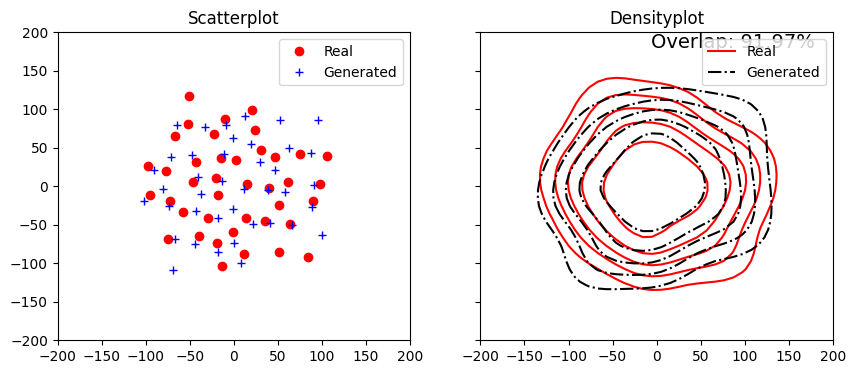

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


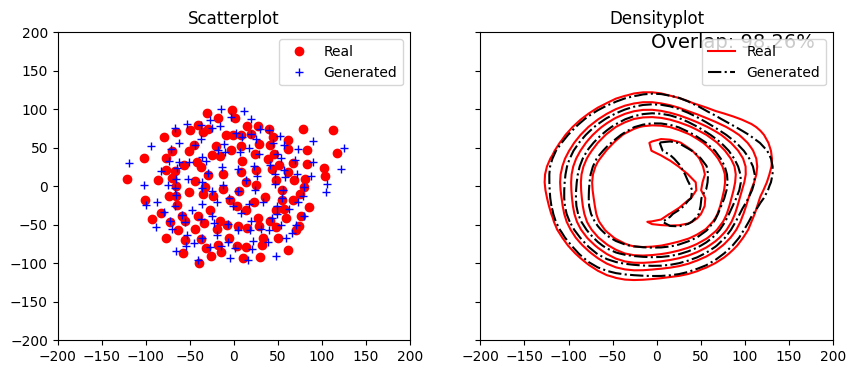

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


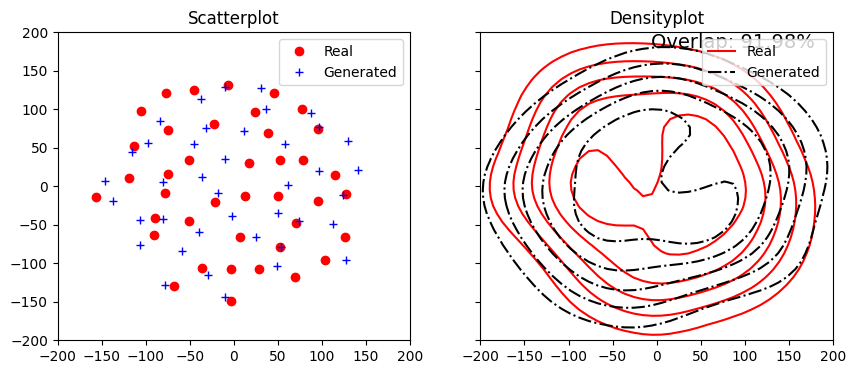


--- Facies CDF Plots ---
Validation set:


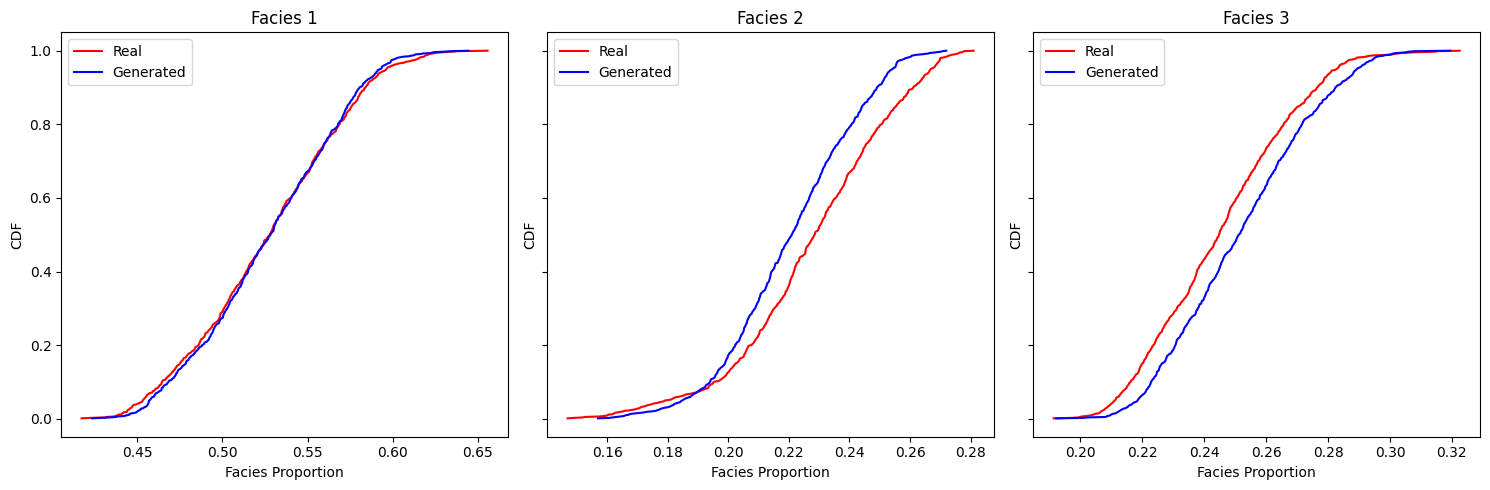

Train set:


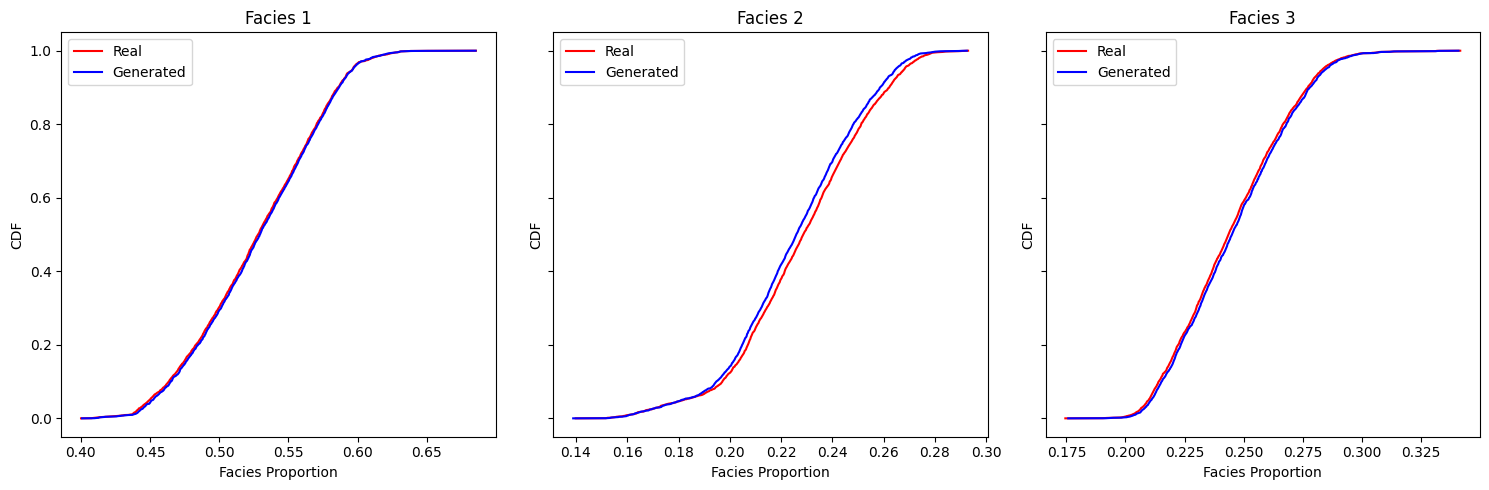

Test set:


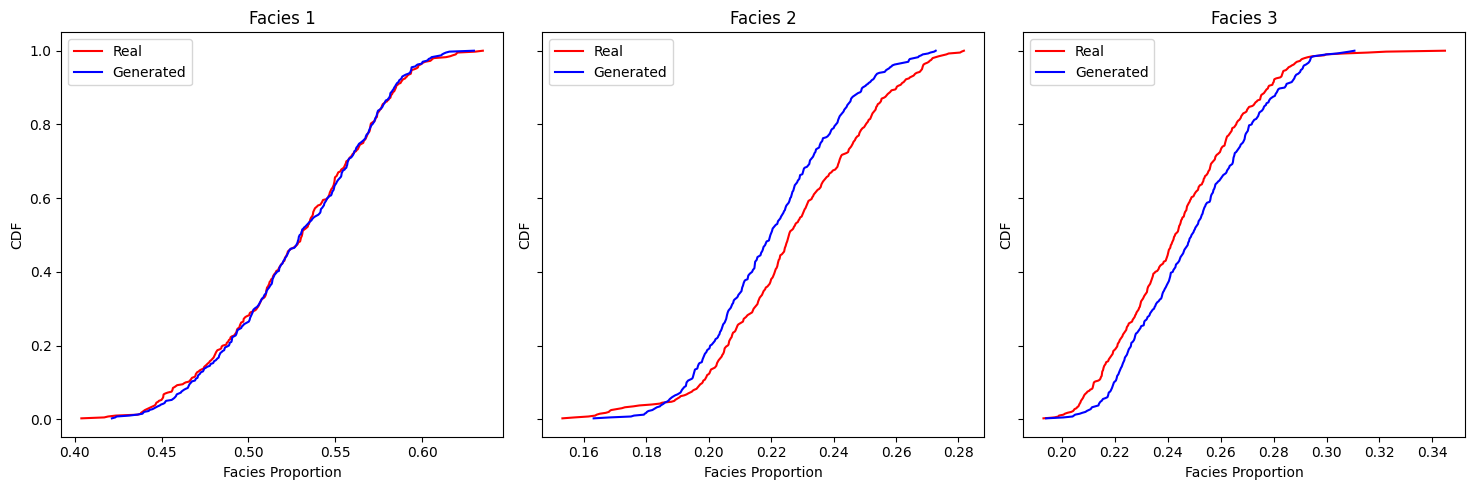


MODEL 2: Guido F8 Z4
Overlap Variogram:
  - Validation: 95.9798
  - Training:   99.2840
  - Test:       97.2543

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


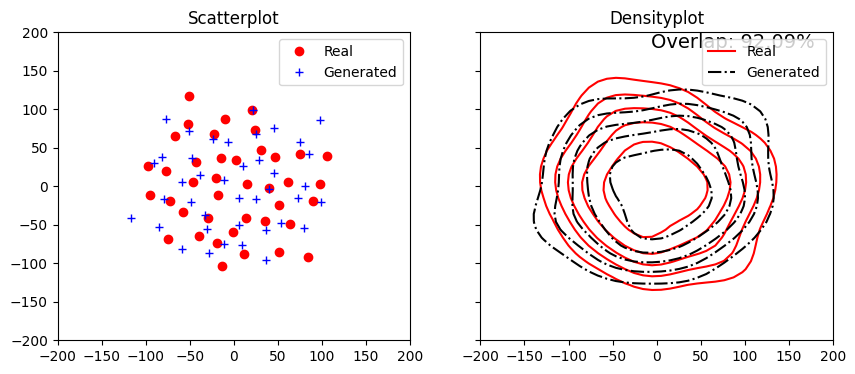

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


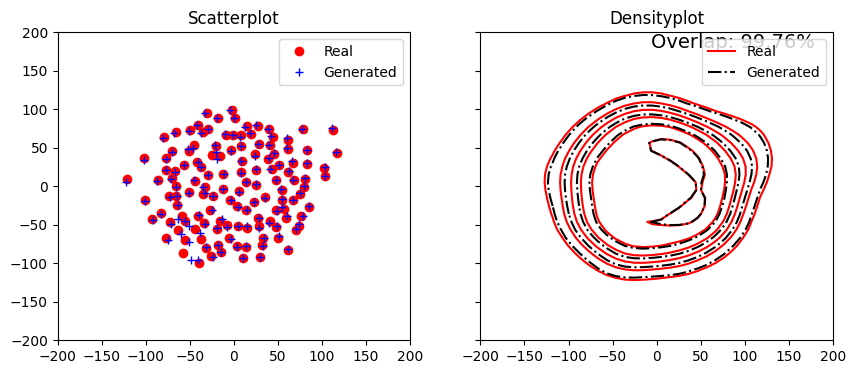

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


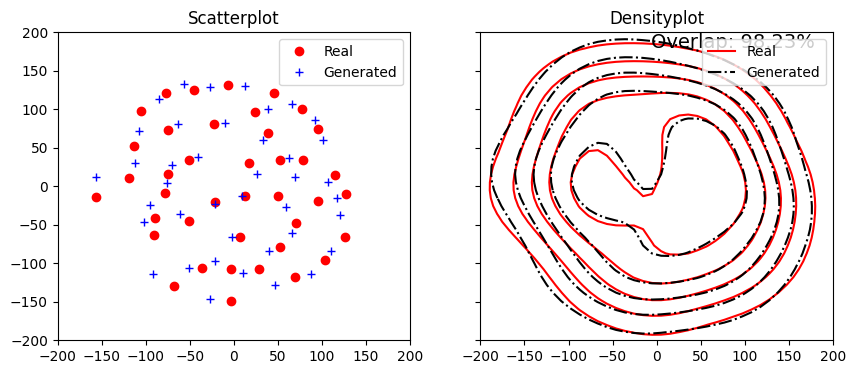


--- Facies CDF Plots ---
Validation set:


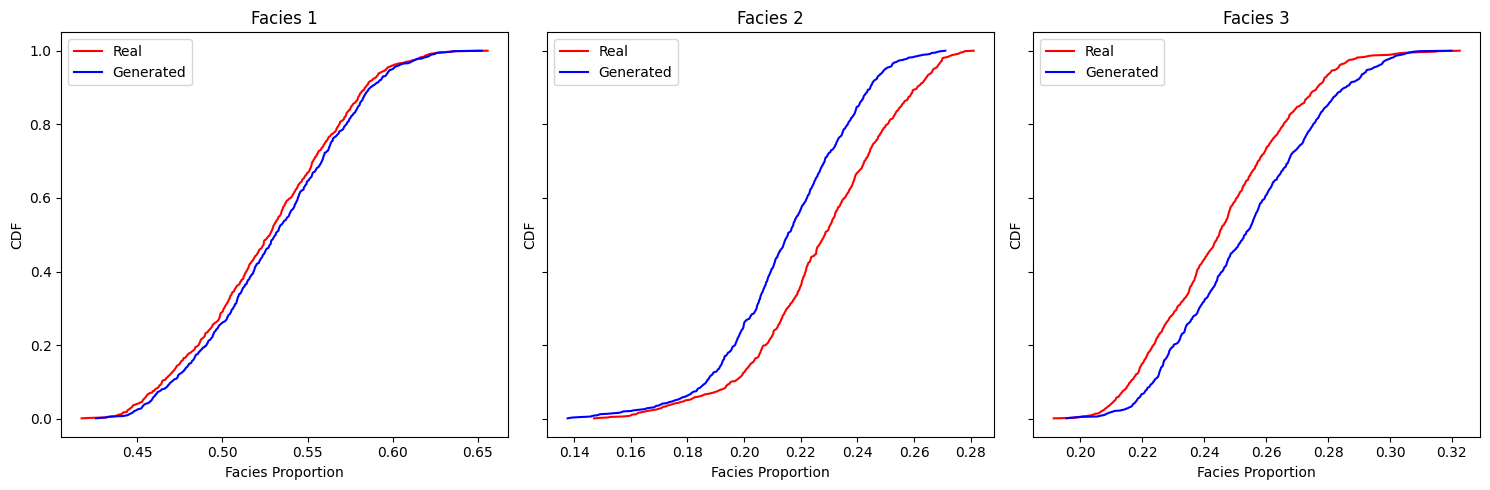

Train set:


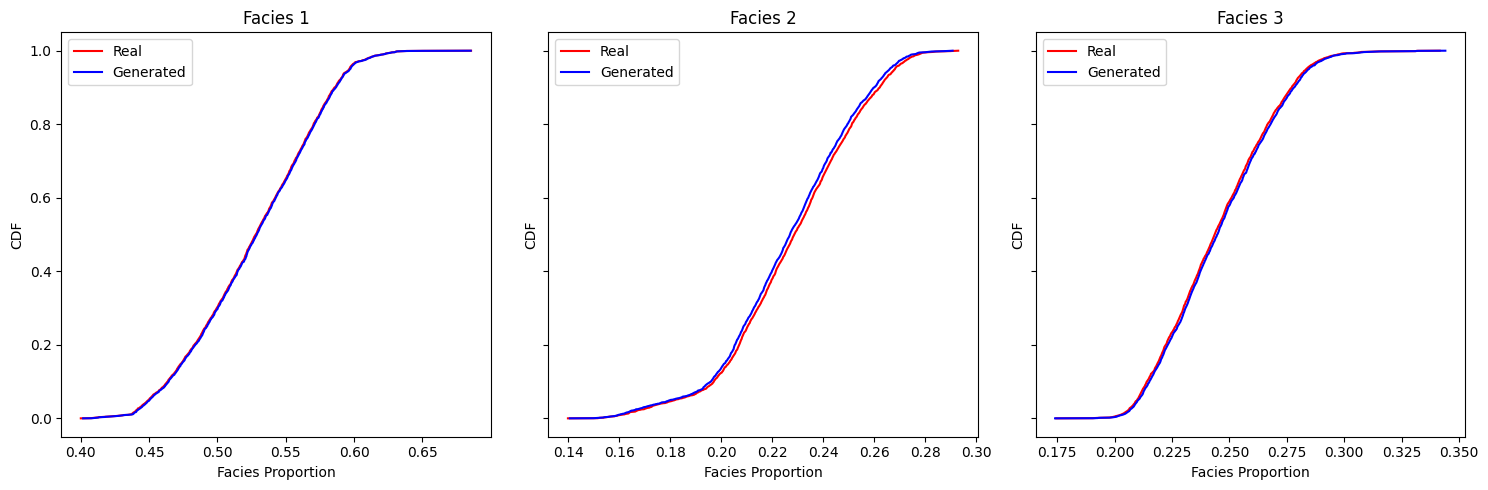

Test set:


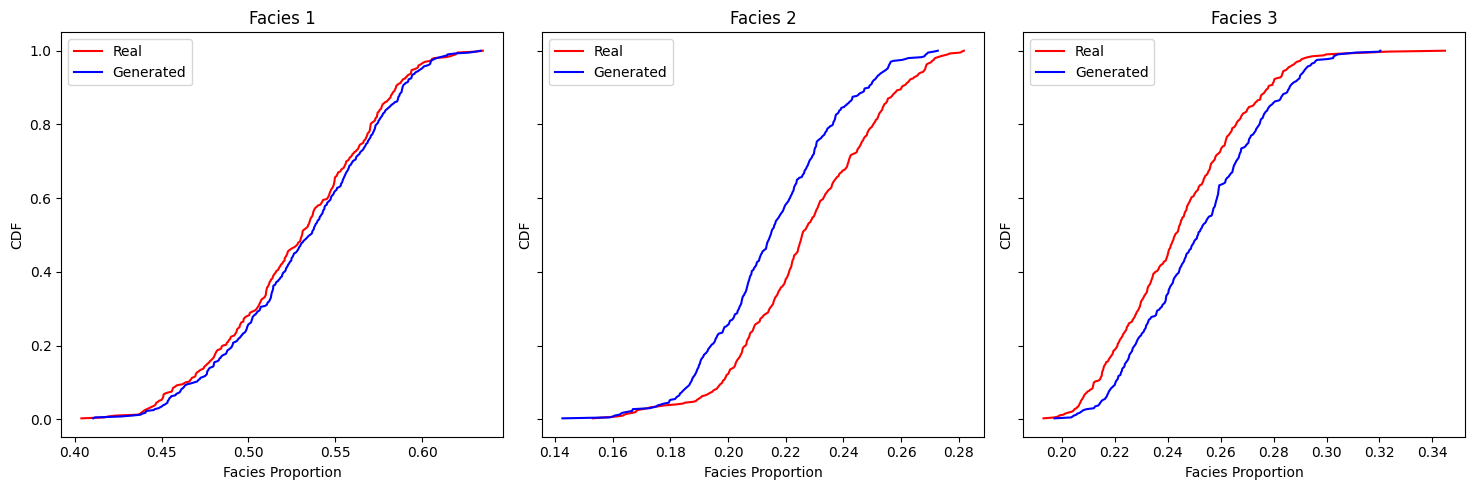


MODEL 3: Tuned F8
Overlap Variogram:
  - Validation: 98.5665
  - Training:   99.7295
  - Test:       99.0545

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


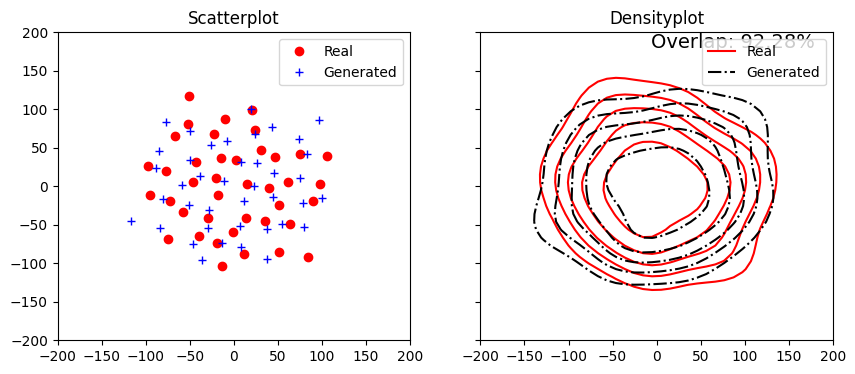

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


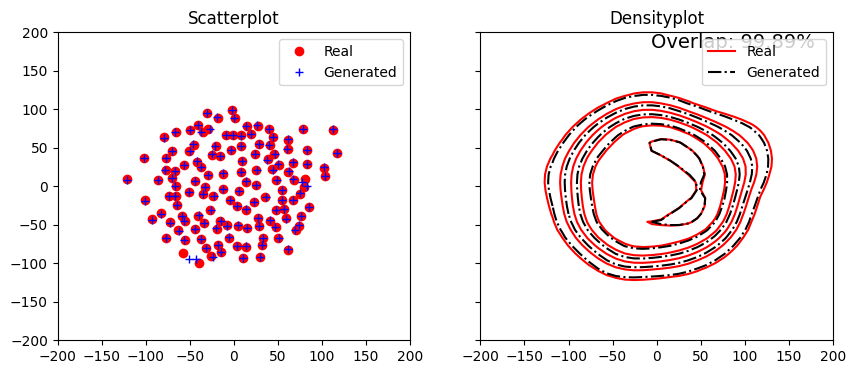

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


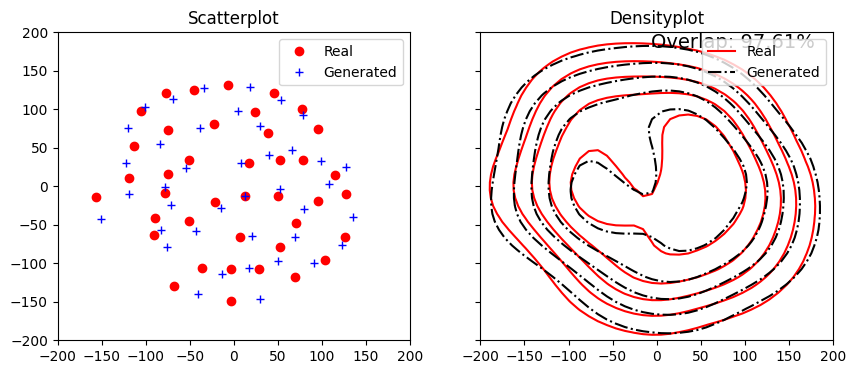


--- Facies CDF Plots ---
Validation set:


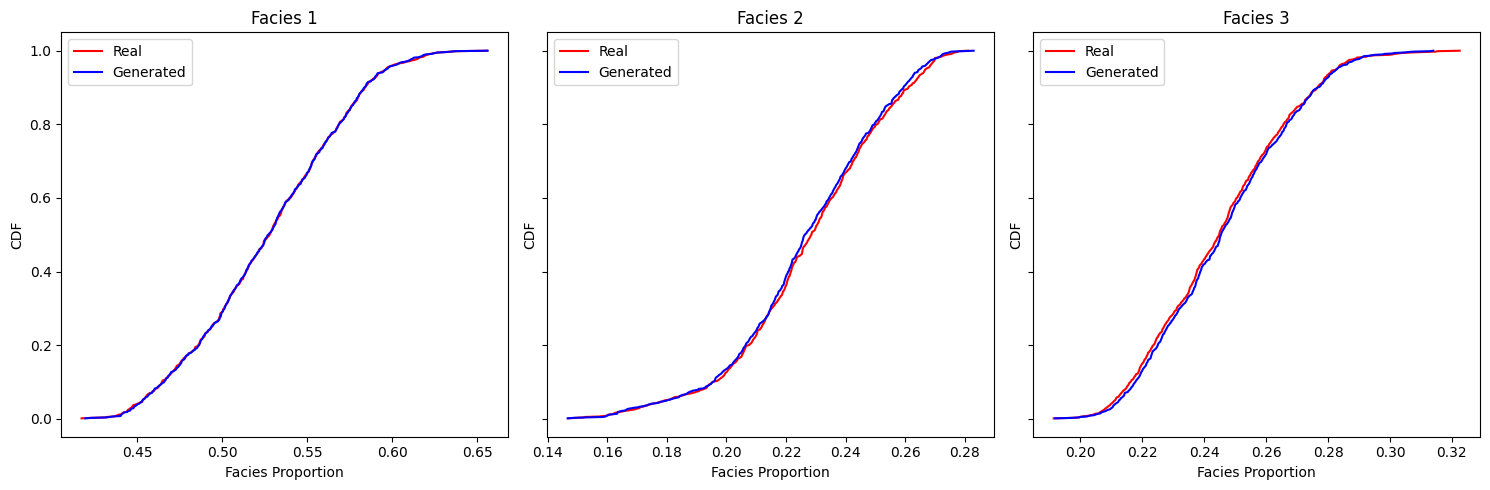

Train set:


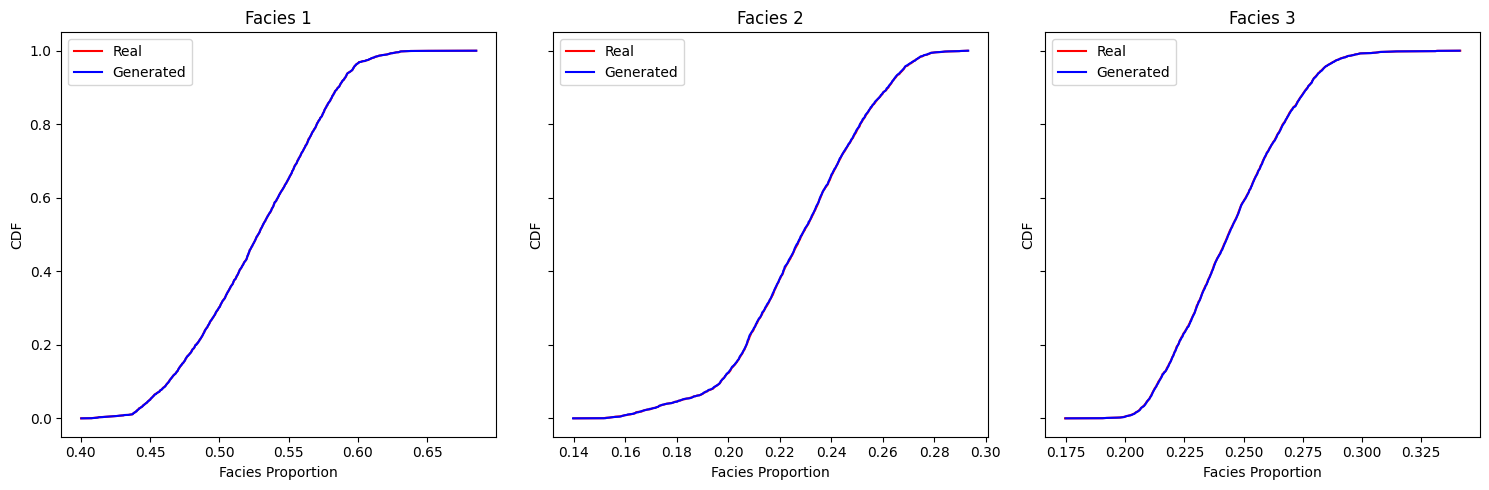

Test set:


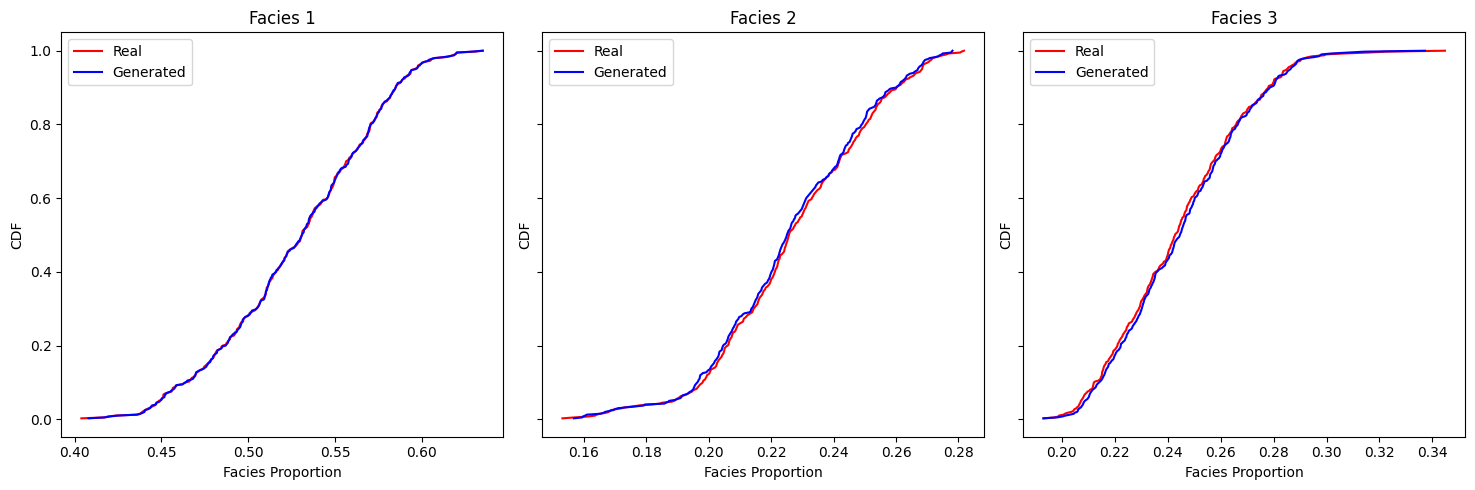


MODEL 4: Tuned F4
Overlap Variogram:
  - Validation: 99.4221
  - Training:   99.5827
  - Test:       99.6226

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


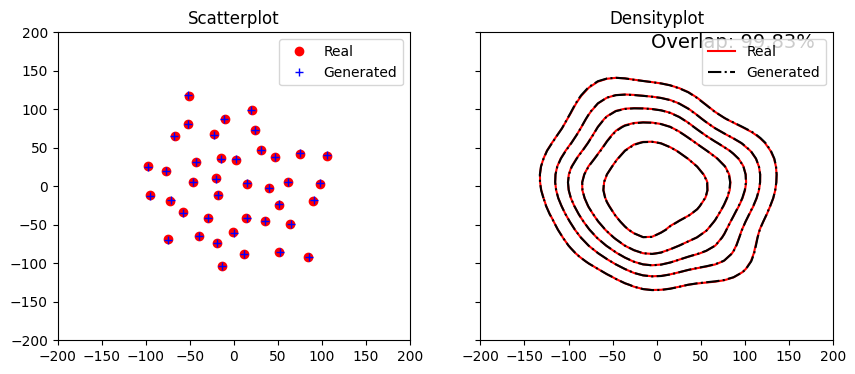

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


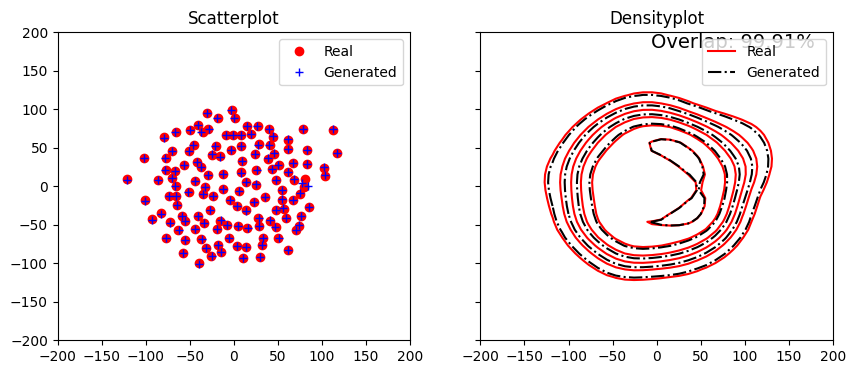

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


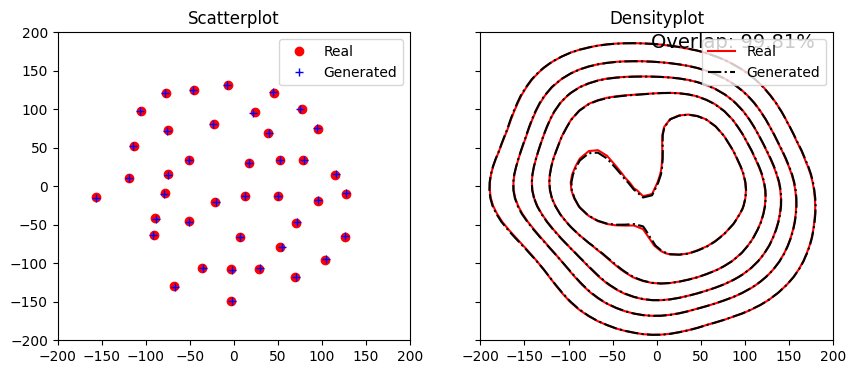


--- Facies CDF Plots ---
Validation set:


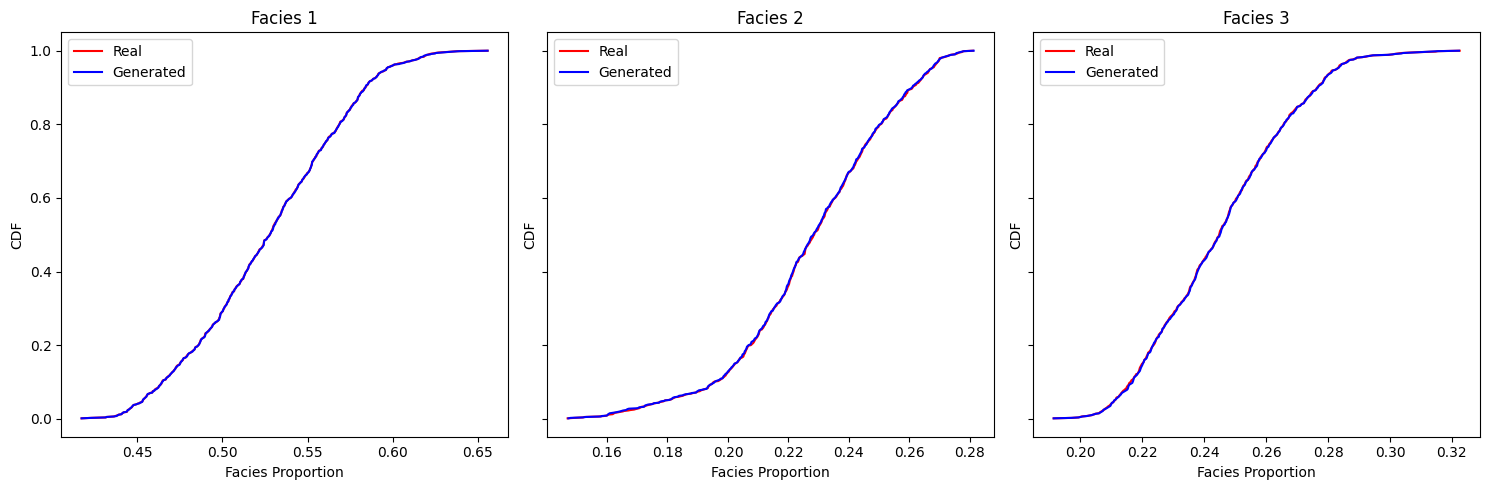

Train set:


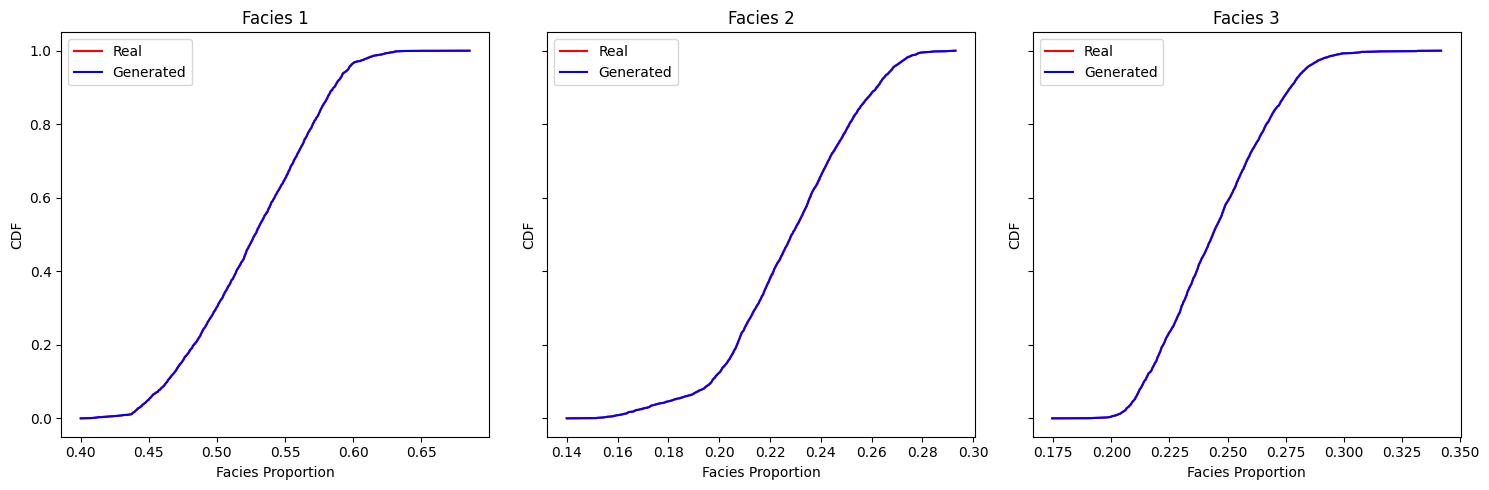

Test set:


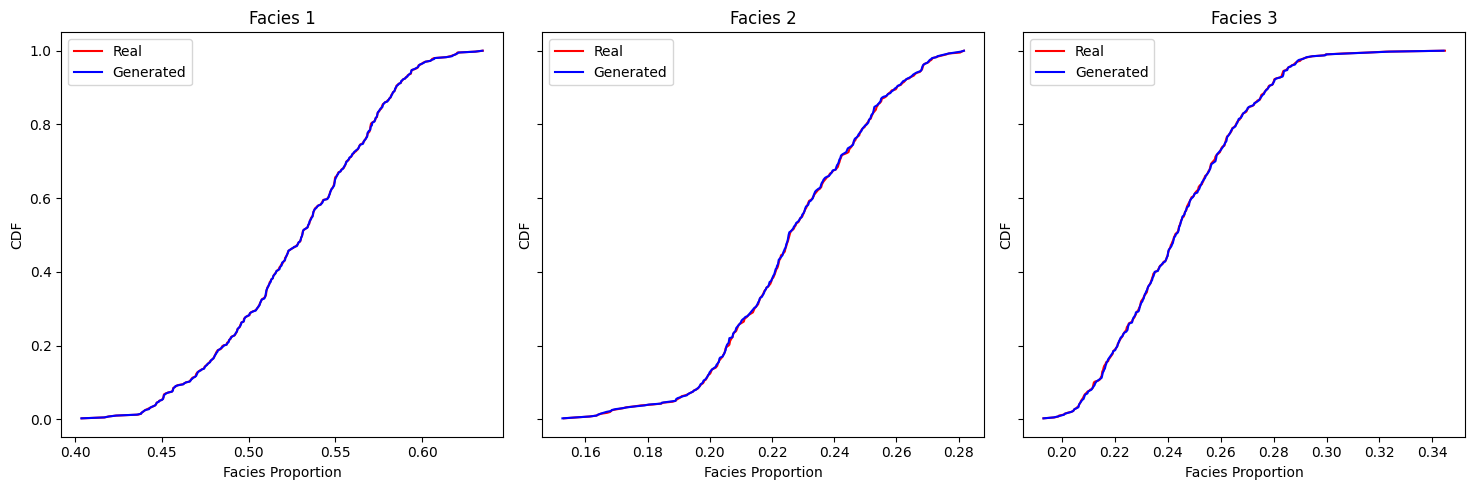


MODEL 5: SD F8 C128 R2
Overlap Variogram:
  - Validation: 97.8012
  - Training:   99.3103
  - Test:       98.0321

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


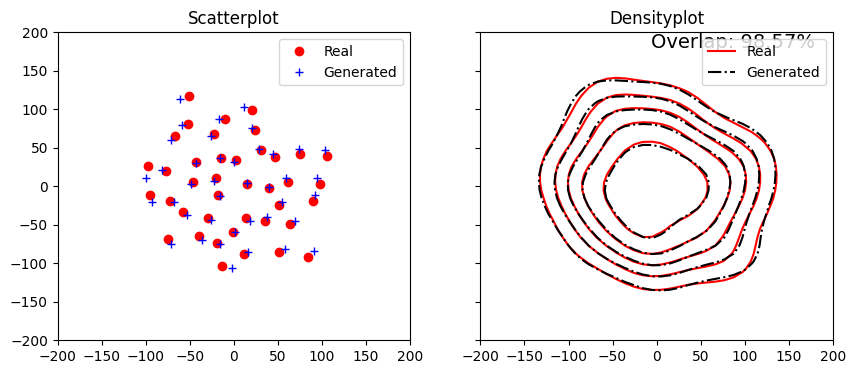

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


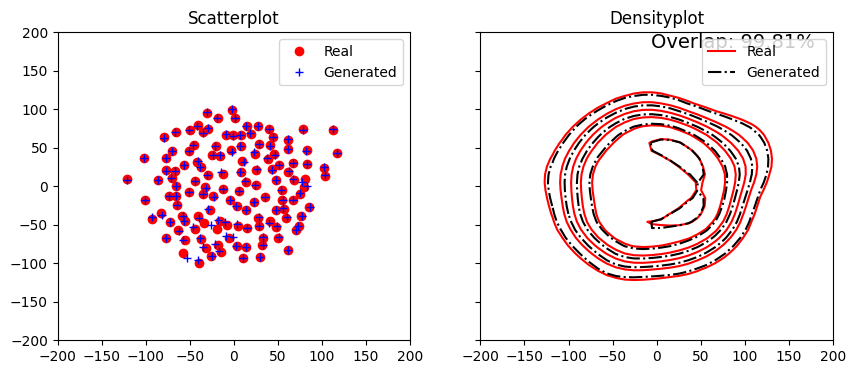

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


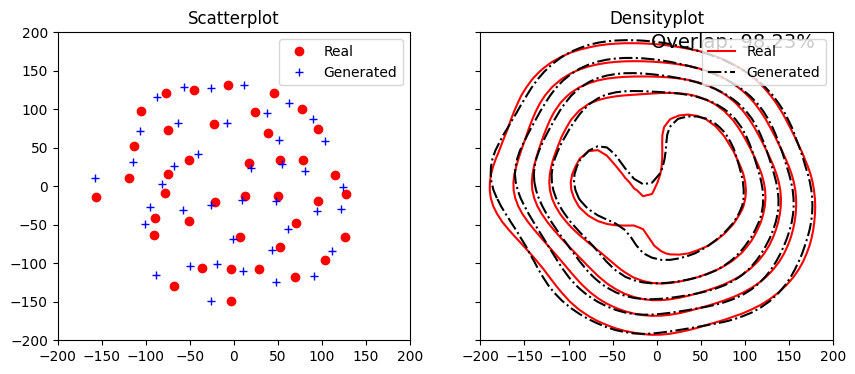


--- Facies CDF Plots ---
Validation set:


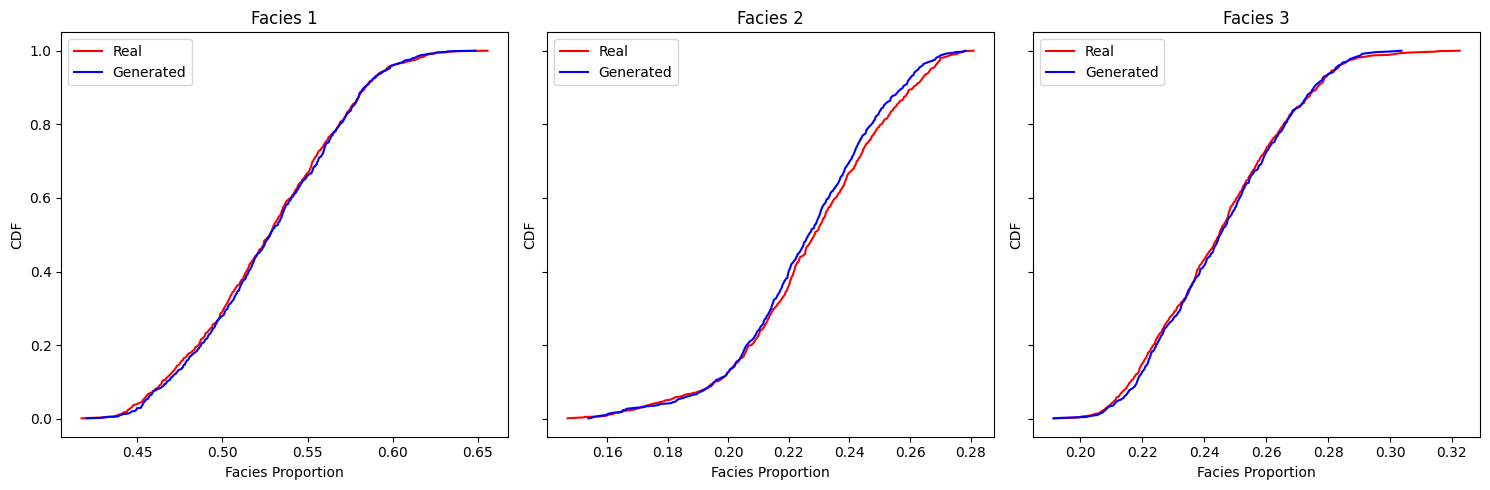

Train set:


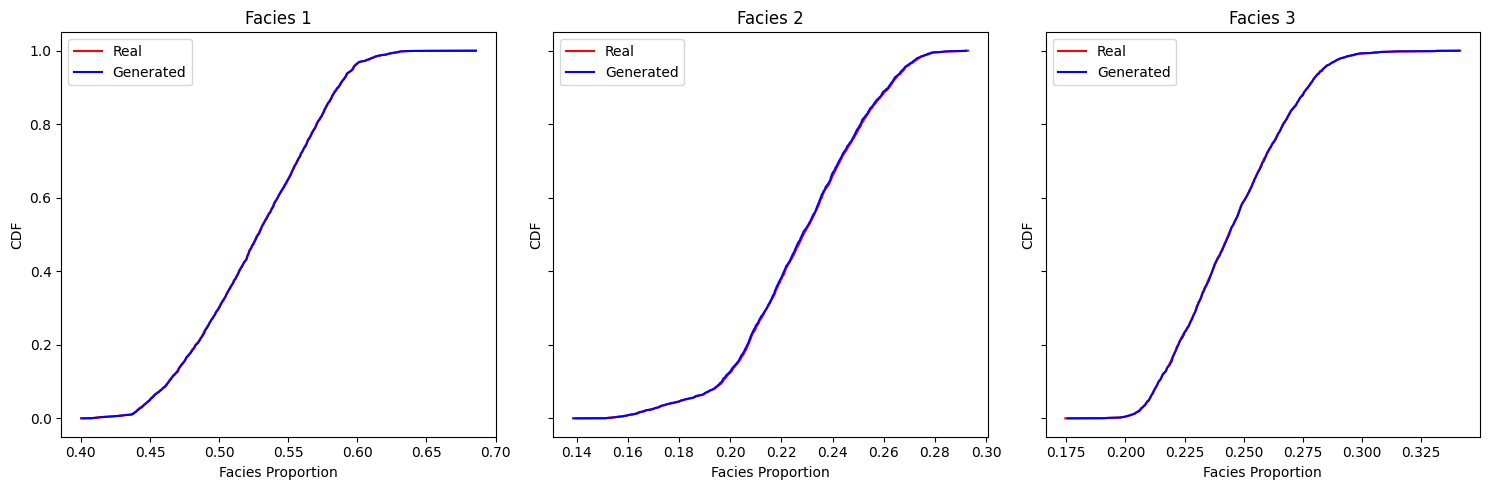

Test set:


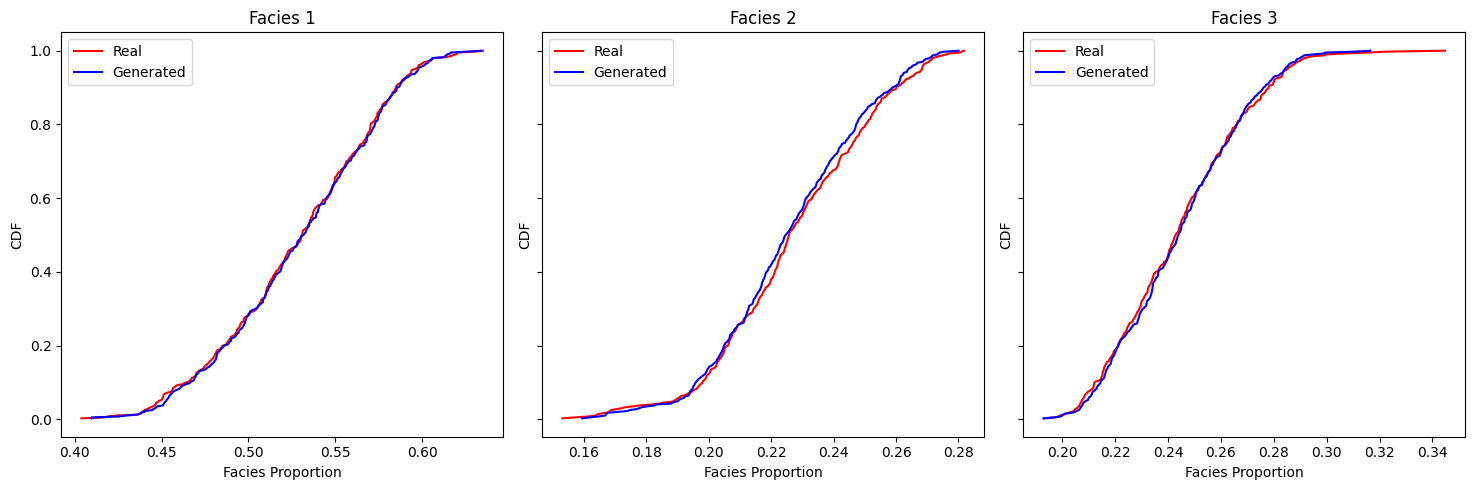


MODEL 6: SD F8 C64 R2
Overlap Variogram:
  - Validation: 96.8551
  - Training:   99.4007
  - Test:       97.1340

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


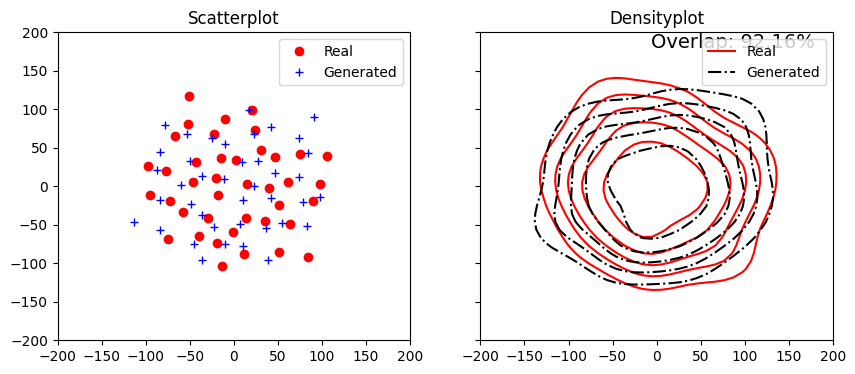

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


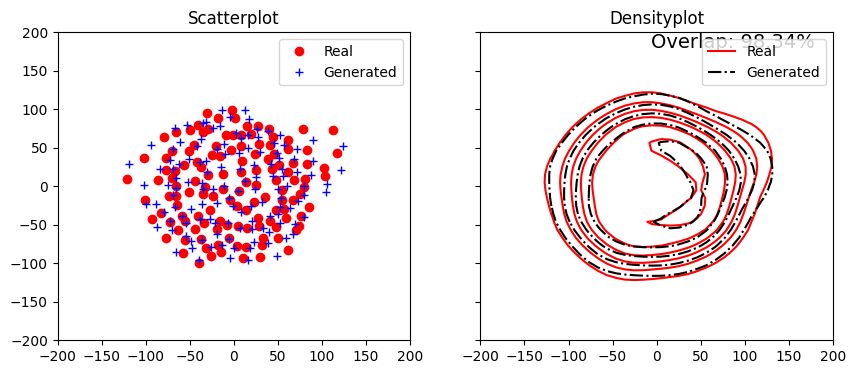

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


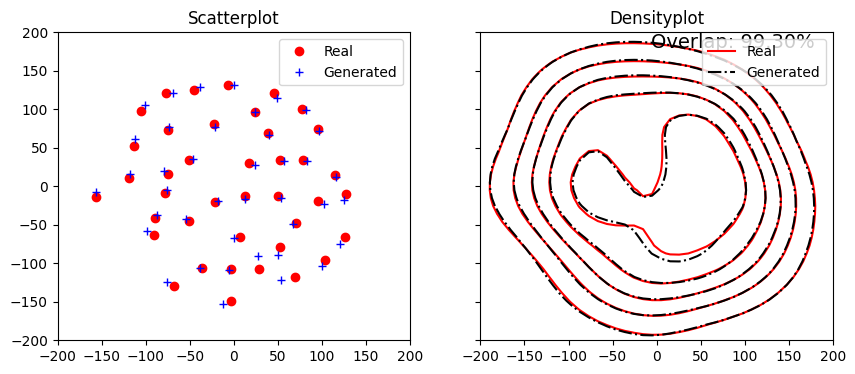


--- Facies CDF Plots ---
Validation set:


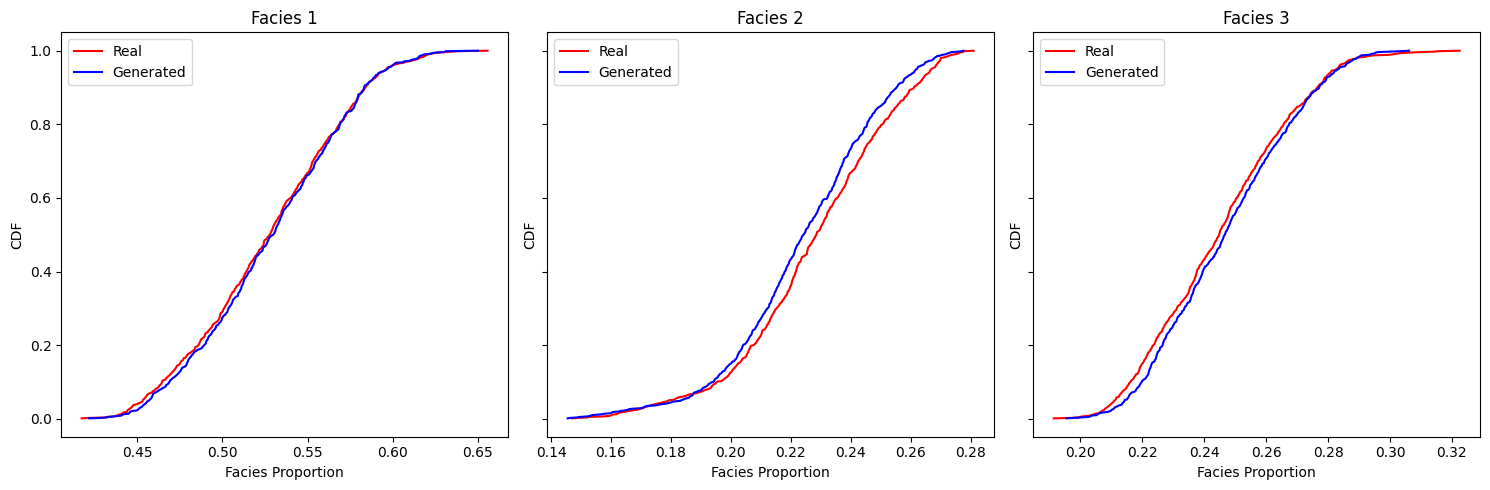

Train set:


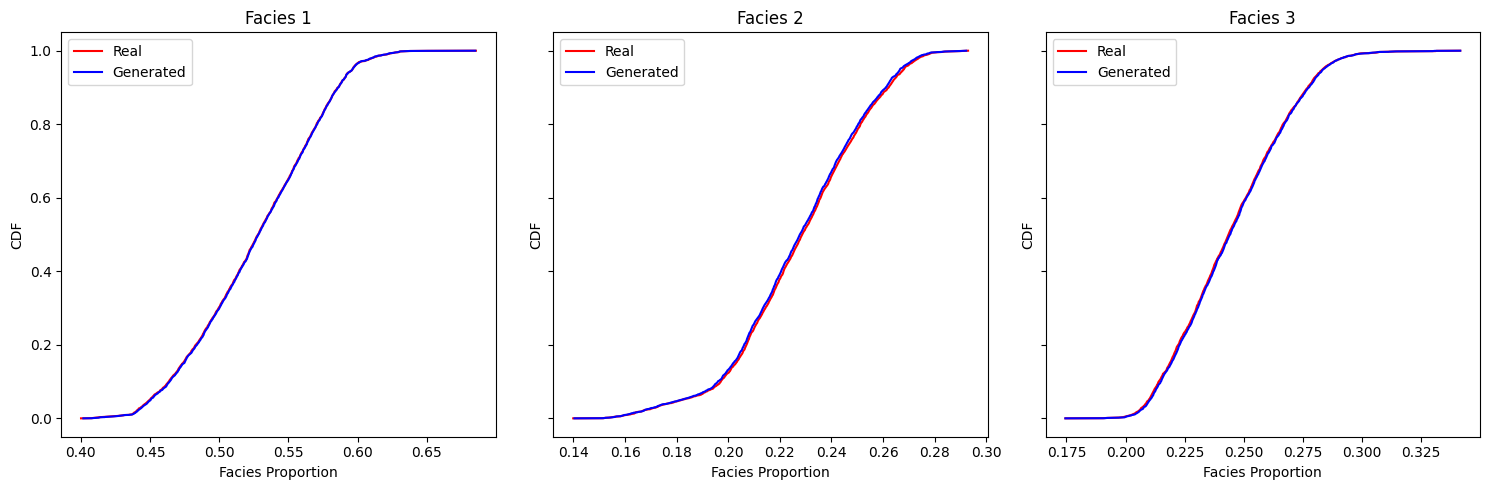

Test set:


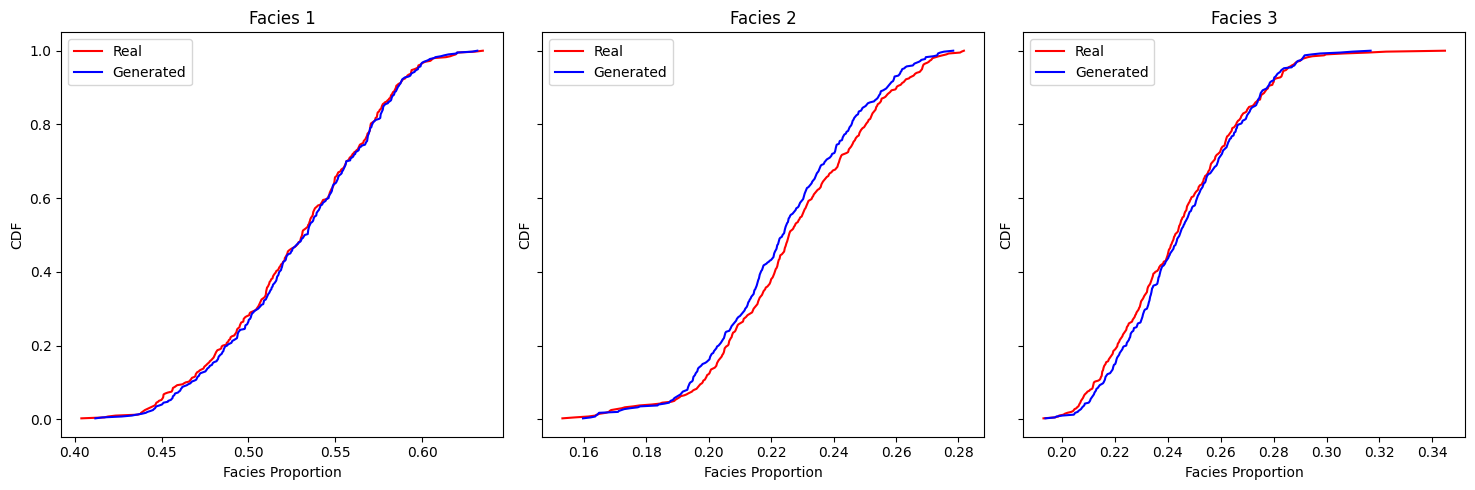


MODEL 7: SD F8 C64 R1
Overlap Variogram:
  - Validation: 96.6025
  - Training:   98.8661
  - Test:       97.0290

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


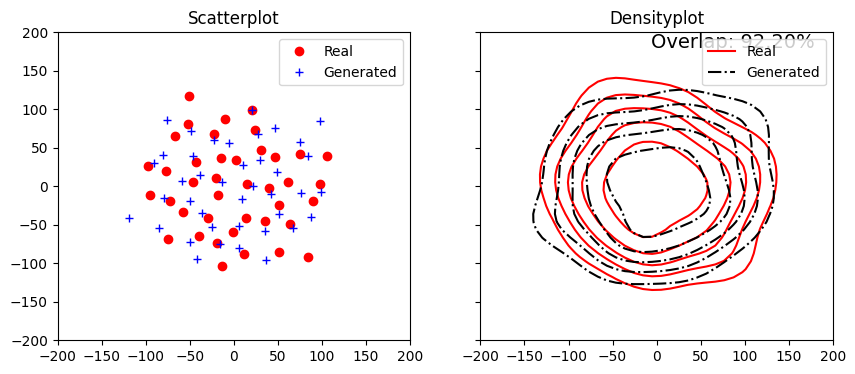

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


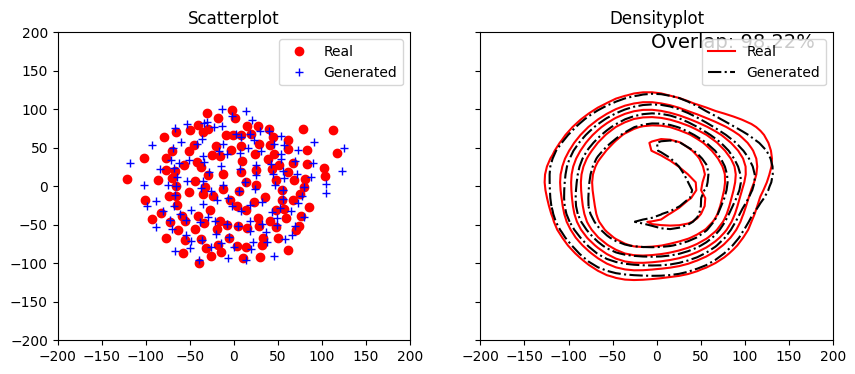

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


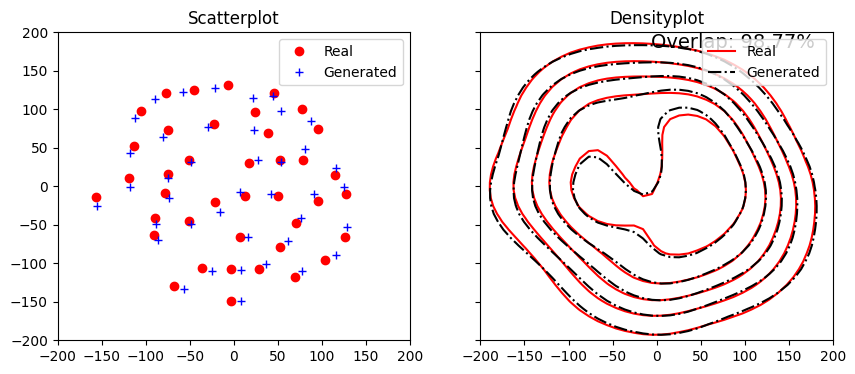


--- Facies CDF Plots ---
Validation set:


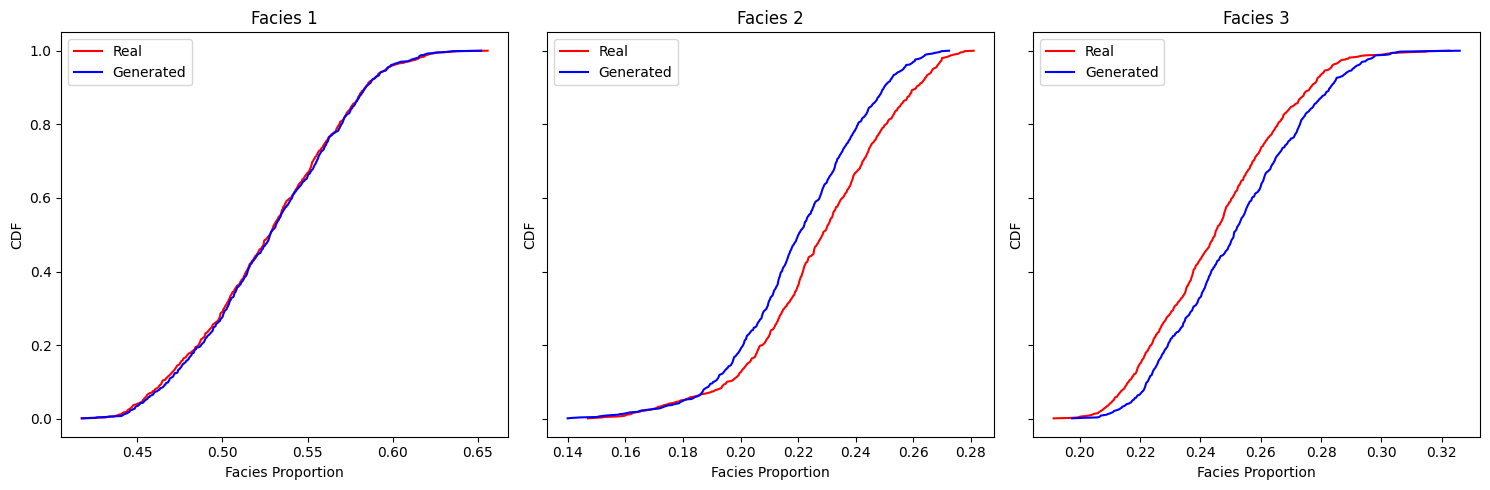

Train set:


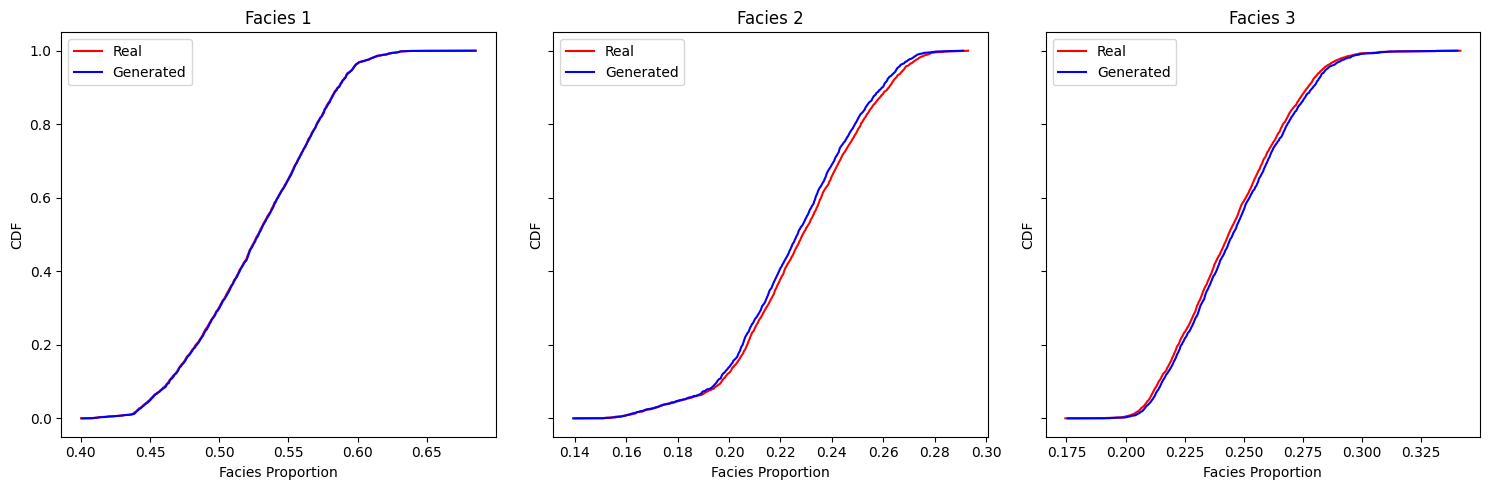

Test set:


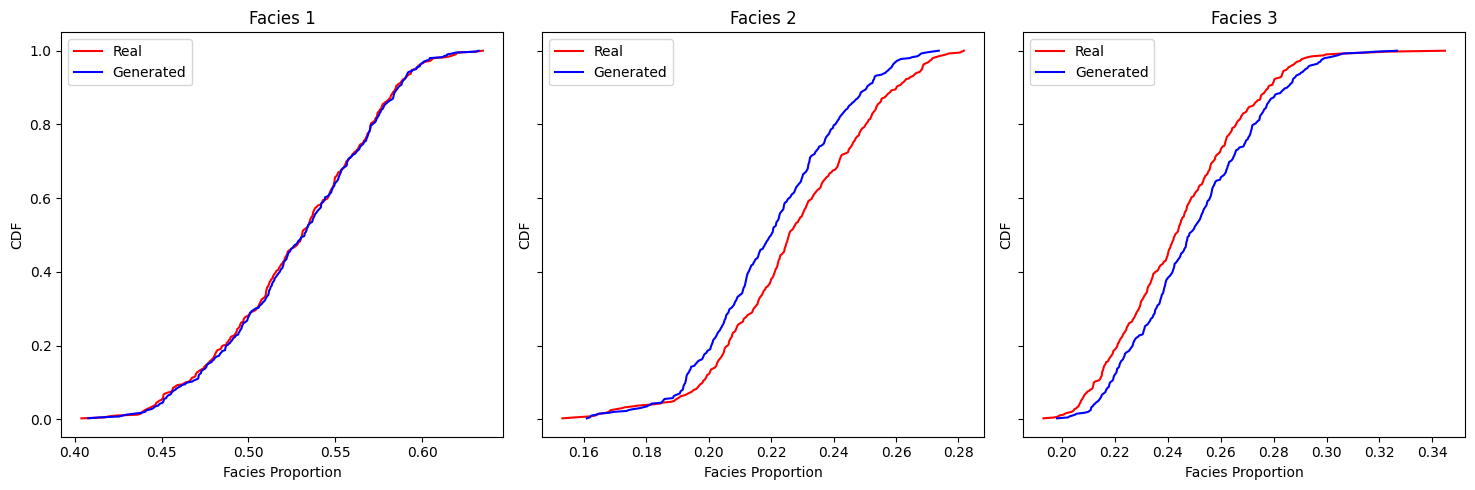


MODEL 8: SD F4 C128 R2
Overlap Variogram:
  - Validation: 98.7448
  - Training:   99.7003
  - Test:       99.0774

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


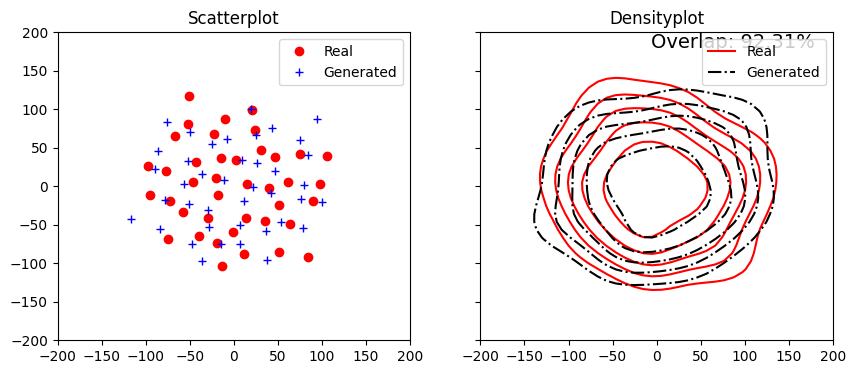

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


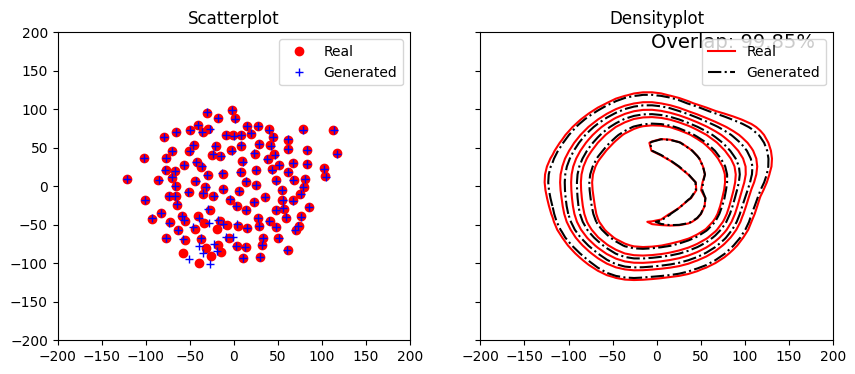

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


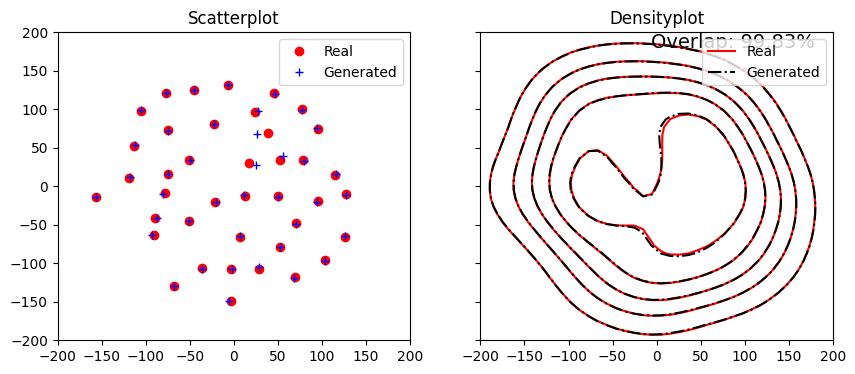


--- Facies CDF Plots ---
Validation set:


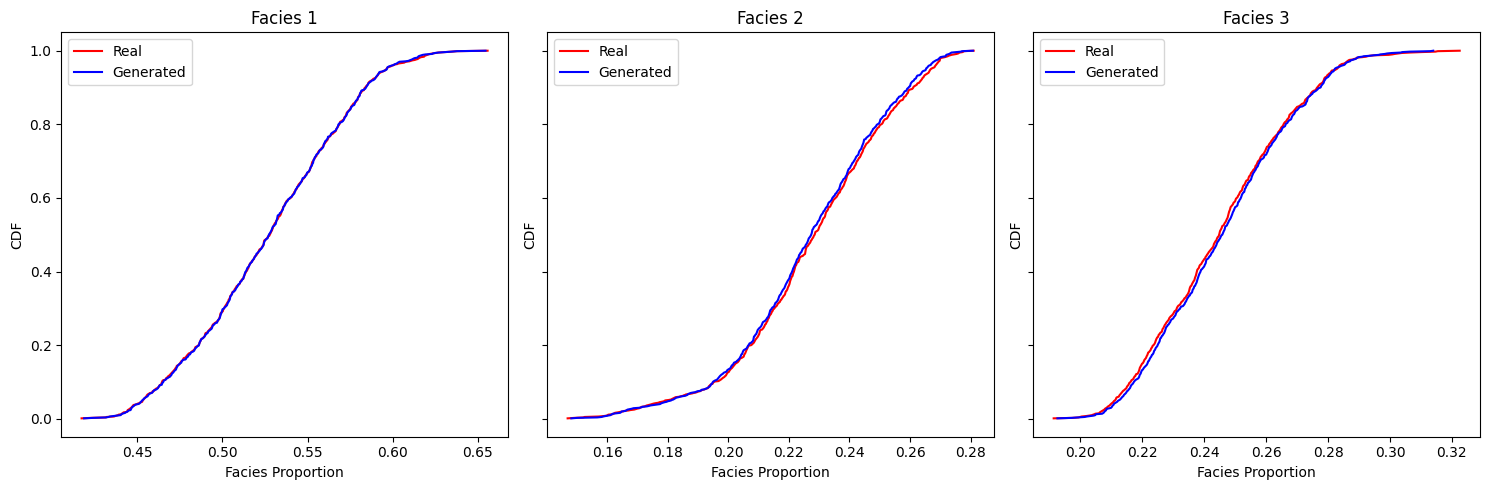

Train set:


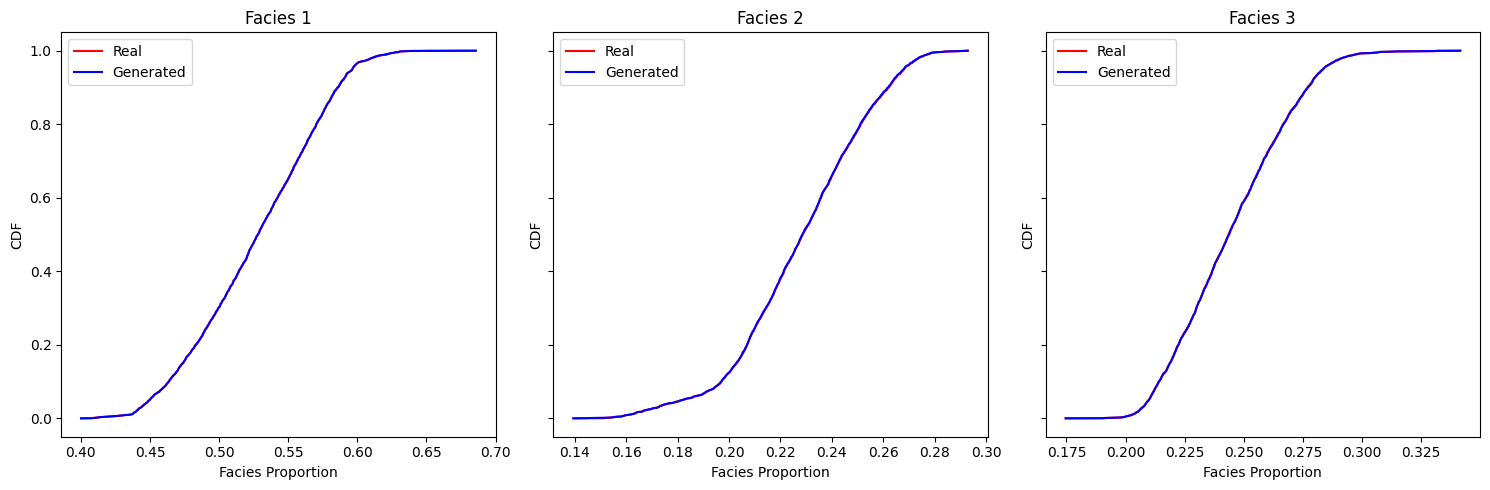

Test set:


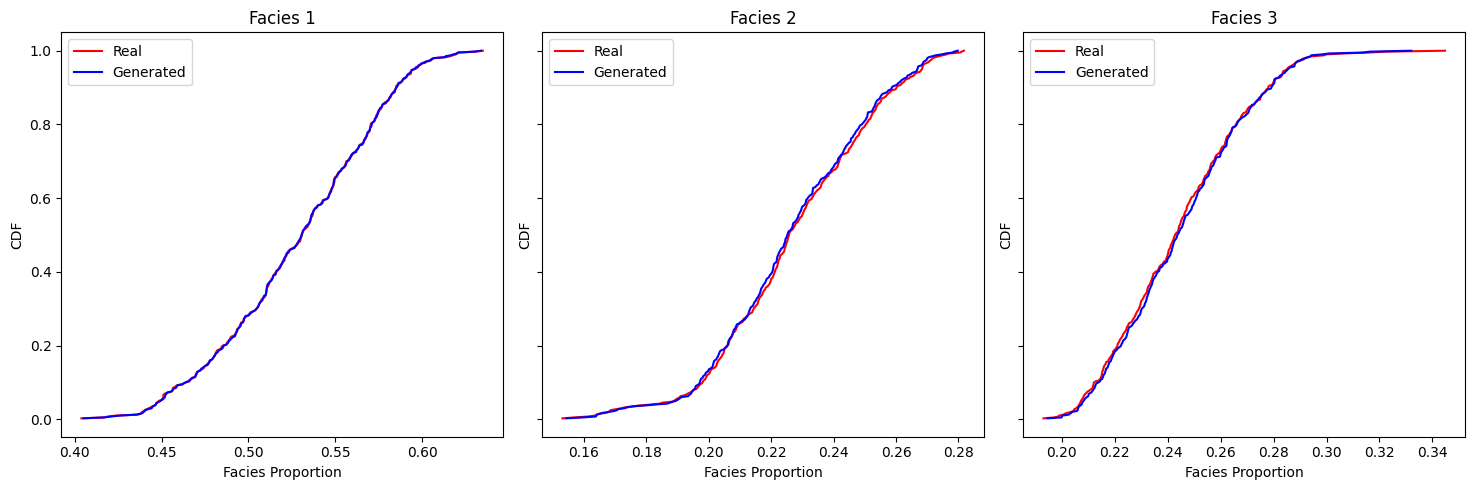


MODEL 9: SD F4 C64 R1
Overlap Variogram:
  - Validation: 98.5527
  - Training:   99.7941
  - Test:       98.5499

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


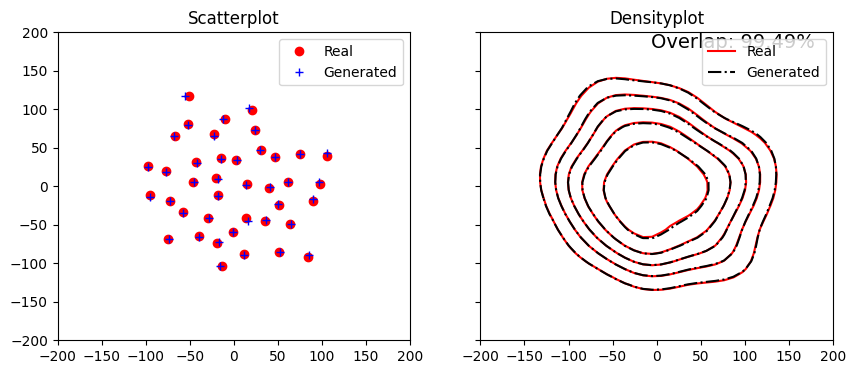

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


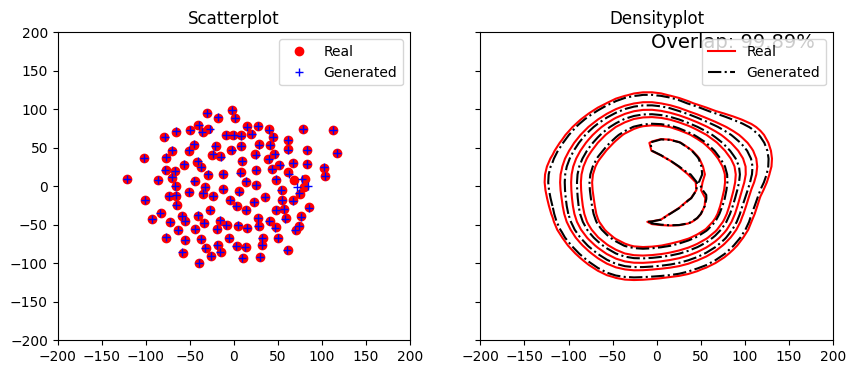

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


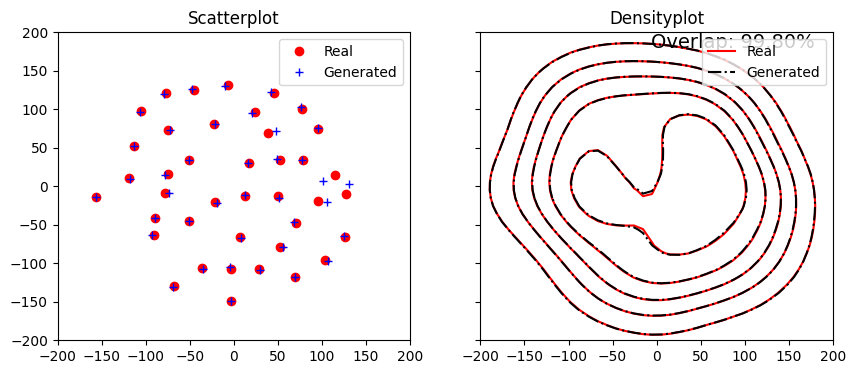


--- Facies CDF Plots ---
Validation set:


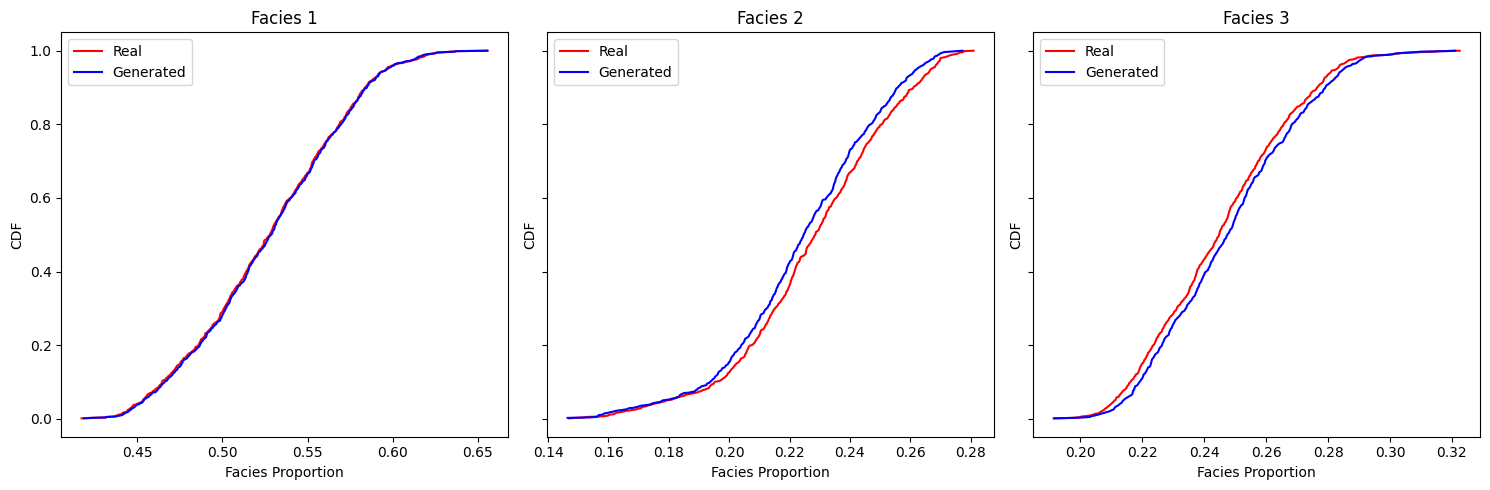

Train set:


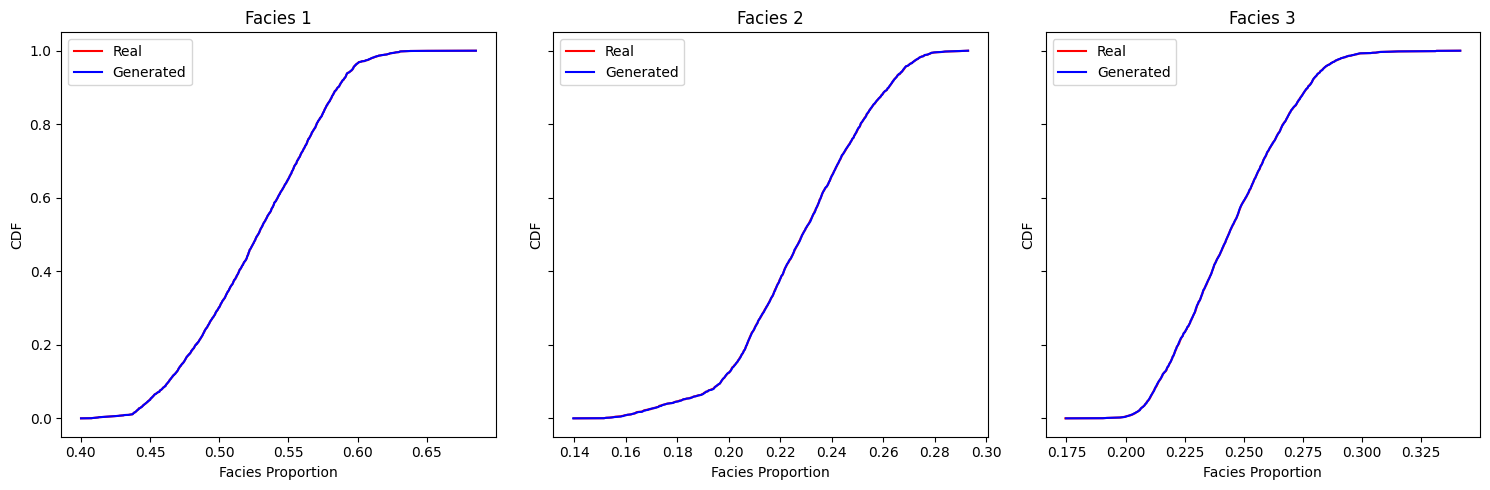

Test set:


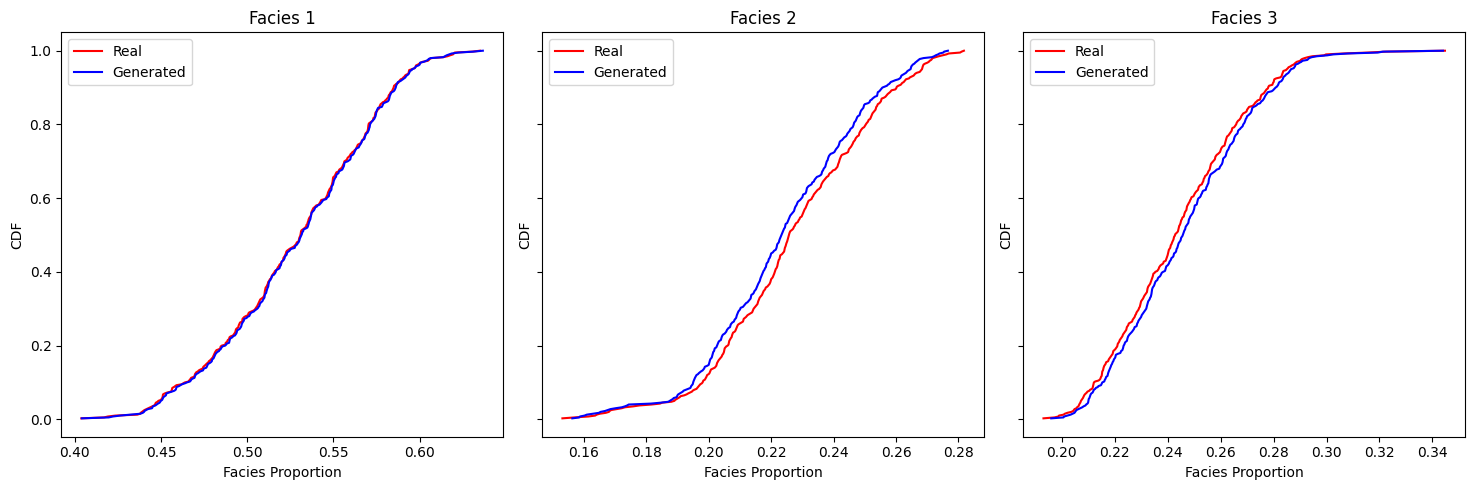


MODEL 10: SD F4 C64 R2
Overlap Variogram:
  - Validation: 98.5198
  - Training:   99.7107
  - Test:       98.7554

--- MSSWD MDS Plots ---
Validation set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


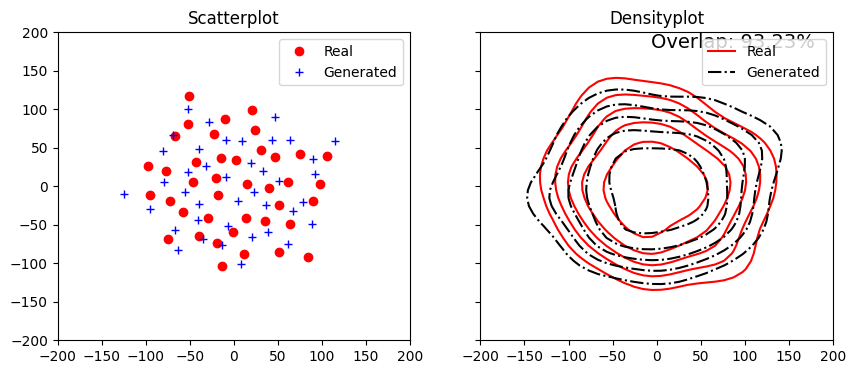

Train set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


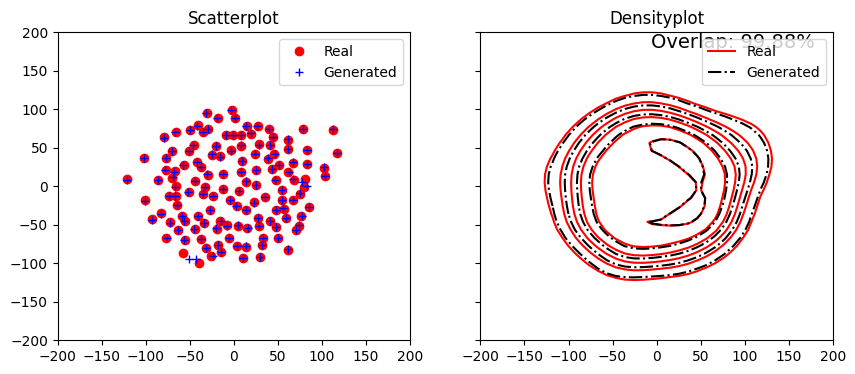

Test set:


The default value of `n_init` will change from 4 to 1 in 1.9.
The default value of `n_init` will change from 4 to 1 in 1.9.


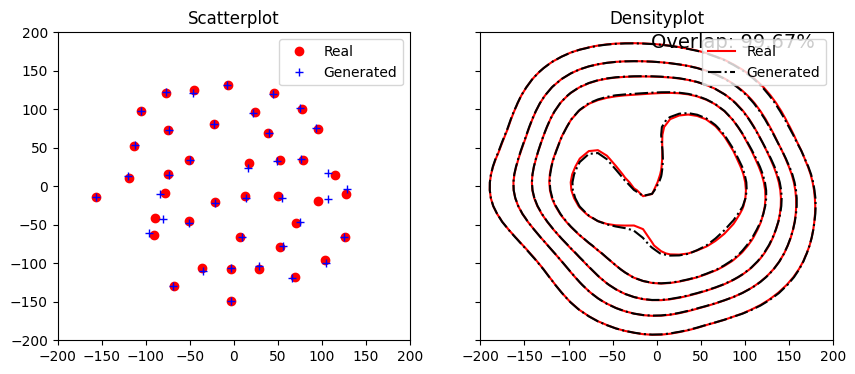


--- Facies CDF Plots ---
Validation set:


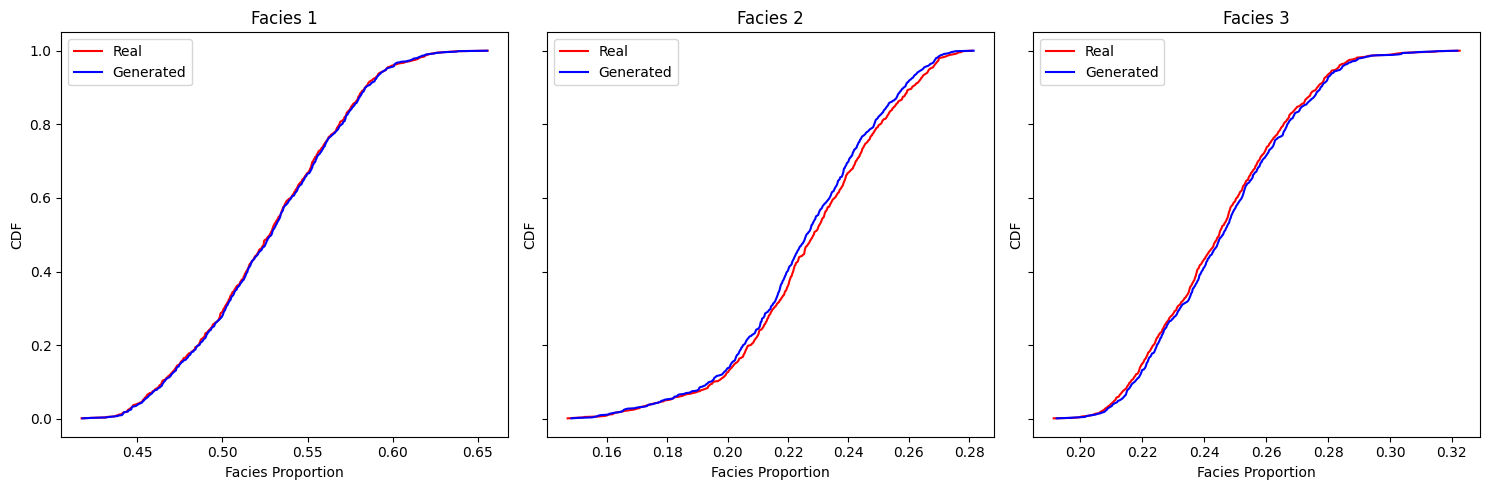

Train set:


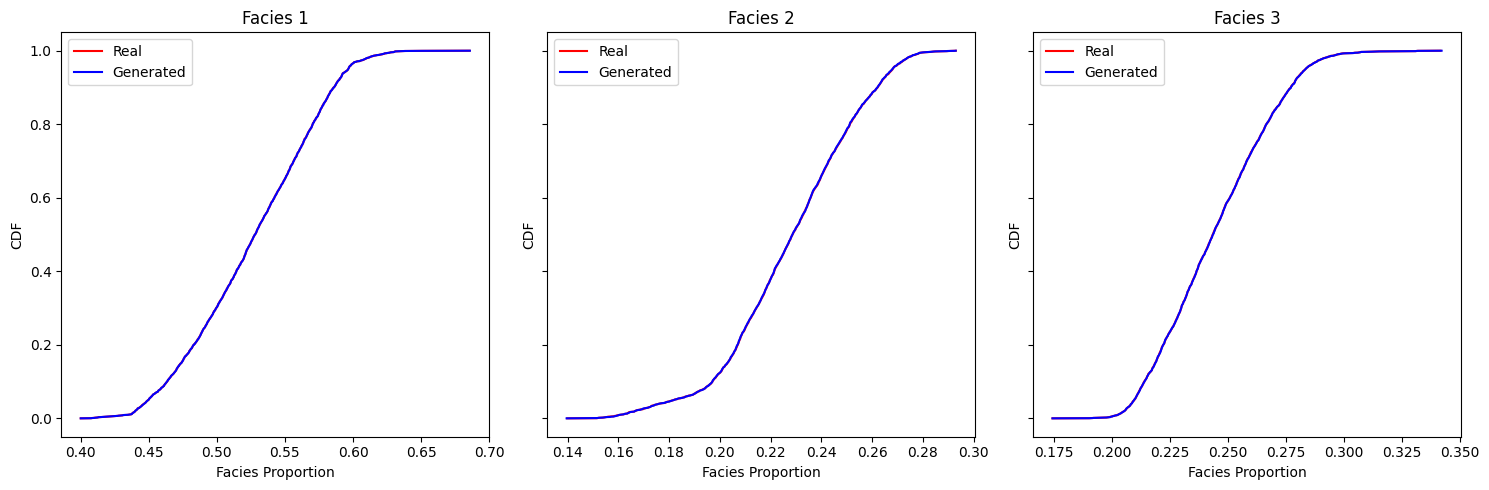

Test set:


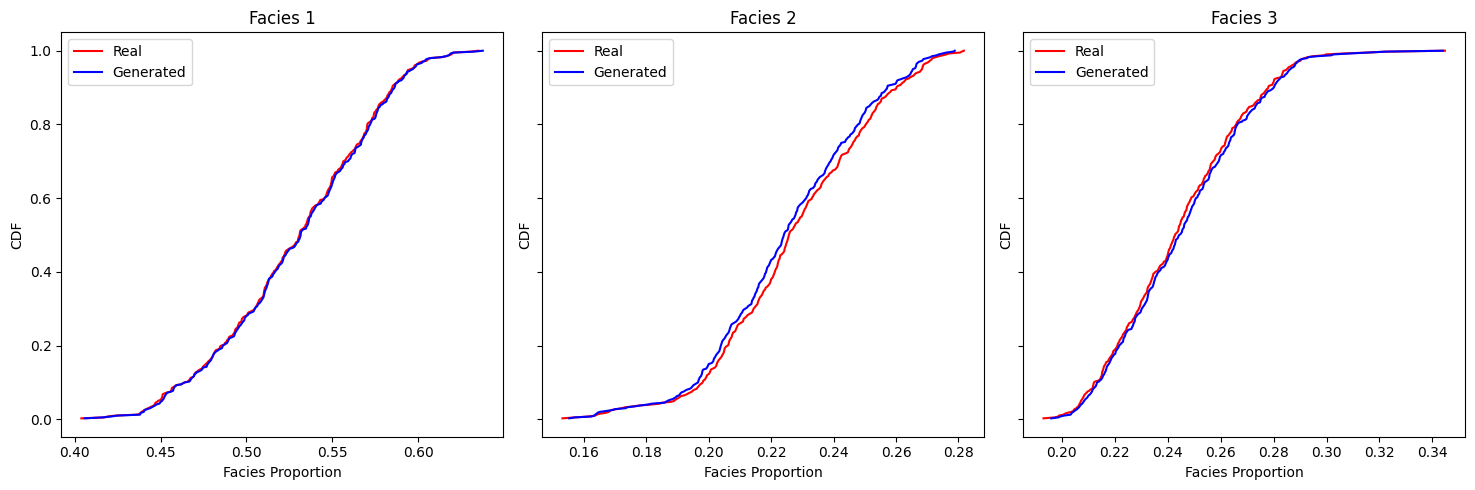

In [15]:
# Number of samples to randomly pick
num_samples_variogram = 200
# Randomly pick indices for validation, training, and test sets
val_indices_variogram = np.random.RandomState(42).choice(original_images.shape[0], num_samples_variogram, replace=False)
train_indices_variogram = np.random.RandomState(42).choice(original_images_train.shape[0], num_samples_variogram, replace=False)
test_indices_variogram = np.random.RandomState(42).choice(original_images_test.shape[0], num_samples_variogram, replace=False)

overlap_variograms_val, overlap_variograms_train, overlap_variograms_test = [], [], []
overlap_densities_val, overlap_densities_train, overlap_densities_test = [], [], []
for i in range(len(autoencoders)):
    
    overlap_variogram_val = calculate_variogram_overlap(
        np.asarray(original_images[val_indices_variogram].squeeze(1).cpu()), 
        np.asarray(all_reconstructions[i][val_indices_variogram].squeeze(1).cpu()), 
        Range=-1
    )
    overlap_variogram_train = calculate_variogram_overlap(
        np.asarray(original_images_train[train_indices_variogram].squeeze(1).cpu()), 
        np.asarray(all_reconstructions_train[i][train_indices_variogram].squeeze(1).cpu()), 
        Range=-1
    )
    overlap_variogram_test = calculate_variogram_overlap(
        np.asarray(original_images_test[test_indices_variogram].squeeze(1).cpu()), 
        np.asarray(all_reconstructions_test[i][test_indices_variogram].squeeze(1).cpu()), 
        Range=-1
    )
    overlap_variograms_val.append(overlap_variogram_val)
    overlap_variograms_train.append(overlap_variogram_train)
    overlap_variograms_test.append(overlap_variogram_test)
    
    print(f"\033[1m\nMODEL {i+1}: {model_names[i]}\033[0m")
    print(f"Overlap Variogram:")
    print(f"  - Validation: {overlap_variogram_val:.4f}")
    print(f"  - Training:   {overlap_variogram_train:.4f}")
    print(f"  - Test:       {overlap_variogram_test:.4f}")
    
    
    
    # MSSWD MDS Plots
    print("\n--- MSSWD MDS Plots ---")
    print("Validation set:")
    overlap_density_val = plot_MSSWD_MDS(original_images.to(device), all_reconstructions[i].to(device), num_groups=40, num_images_per_group=20) # Validation set has 800 images = 40 groups of 20 images
    print("Train set:")
    overlap_density_train = plot_MSSWD_MDS(original_images_train.to(device), all_reconstructions_train[i].to(device), num_groups=130, num_images_per_group=20) # Train set has 2600 images = 130 groups of 20 images
    print("Test set:")
    overlap_density_test = plot_MSSWD_MDS(original_images_test.to(device), all_reconstructions_test[i].to(device), num_groups=40, num_images_per_group=10) # Test set has 800 images = 40 groups of 20 images
    overlap_densities_val.append(overlap_density_val)
    overlap_densities_train.append(overlap_density_train)
    overlap_densities_test.append(overlap_density_test)


    
    # Facies CDF Plots
    print("\n--- Facies CDF Plots ---")
    print("Validation set:")
    plot_facies_cdf(original_images, all_reconstructions[i], n_facies=3)
    print("Train set:")
    plot_facies_cdf(original_images_train, all_reconstructions_train[i], n_facies=3)
    print("Test set:")
    plot_facies_cdf(original_images_test, all_reconstructions_test[i], n_facies=3)
    

In [16]:
df = pd.DataFrame({
    "Model": model_names,
    "MAE (Val)": np.mean(all_mae_scores),
    "Rel. Err. (Val)": np.mean(all_rel_errors),
    "MAE (Train)": np.mean(all_mae_scores_train),
    "Rel. Err. (Train)": np.mean(all_rel_errors_train),
    "MAE (Test)": np.mean(all_mae_scores_test),
    "Rel. Err. (Test)": np.mean(all_rel_errors_test),

    "Variogram (Val)": overlap_variograms_val,
    "Variogram (Train)": overlap_variograms_train,
    "Variogram (Test)": overlap_variograms_test,
    
    "Overlap Density (Val)": overlap_densities_val,
    "Overlap Density (Train)": overlap_densities_train,
    "Overlap Density (Test)": overlap_densities_test
    
})
df

,Model,MAE (Val),Rel. Err. (Val),MAE (Train),Rel. Err. (Train),MAE (Test),Rel. Err. (Test),Variogram (Val),Variogram (Train),Variogram (Test),Overlap Density (Val),Overlap Density (Train),Overlap Density (Test)
0,Guido F8 Original,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,92.959331,98.632639,94.606406,91.968315,98.255650,91.981151
1,Guido F8 Z4,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,95.979823,99.284015,97.254348,92.091144,99.757519,98.229604
2,Tuned F8,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,98.566506,99.729549,99.054476,92.280195,99.887531,97.610330
3,Tuned F4,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,99.422115,99.582662,99.622581,99.826490,99.914946,99.814489
4,SD F8 C128 R2,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,97.801233,99.310305,98.032083,98.573081,99.810219,98.233004
5,SD F8 C64 R2,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,96.855117,99.400694,97.134008,92.155296,98.338437,99.301968
6,SD F8 C64 R1,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,96.602468,98.866066,97.029042,92.198448,98.223290,98.774739
7,SD F4 C128 R2,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,98.744843,99.700286,99.077389,92.313662,99.846328,99.827187
8,SD F4 C64 R1,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,98.552723,99.794117,98.549876,99.492228,99.890857,99.802789
9,SD F4 C64 R2,0.022722,0.615686,0.006128,0.23343,0.022265,0.600176,98.519807,99.710680,98.755434,93.233815,99.880458,99.669628


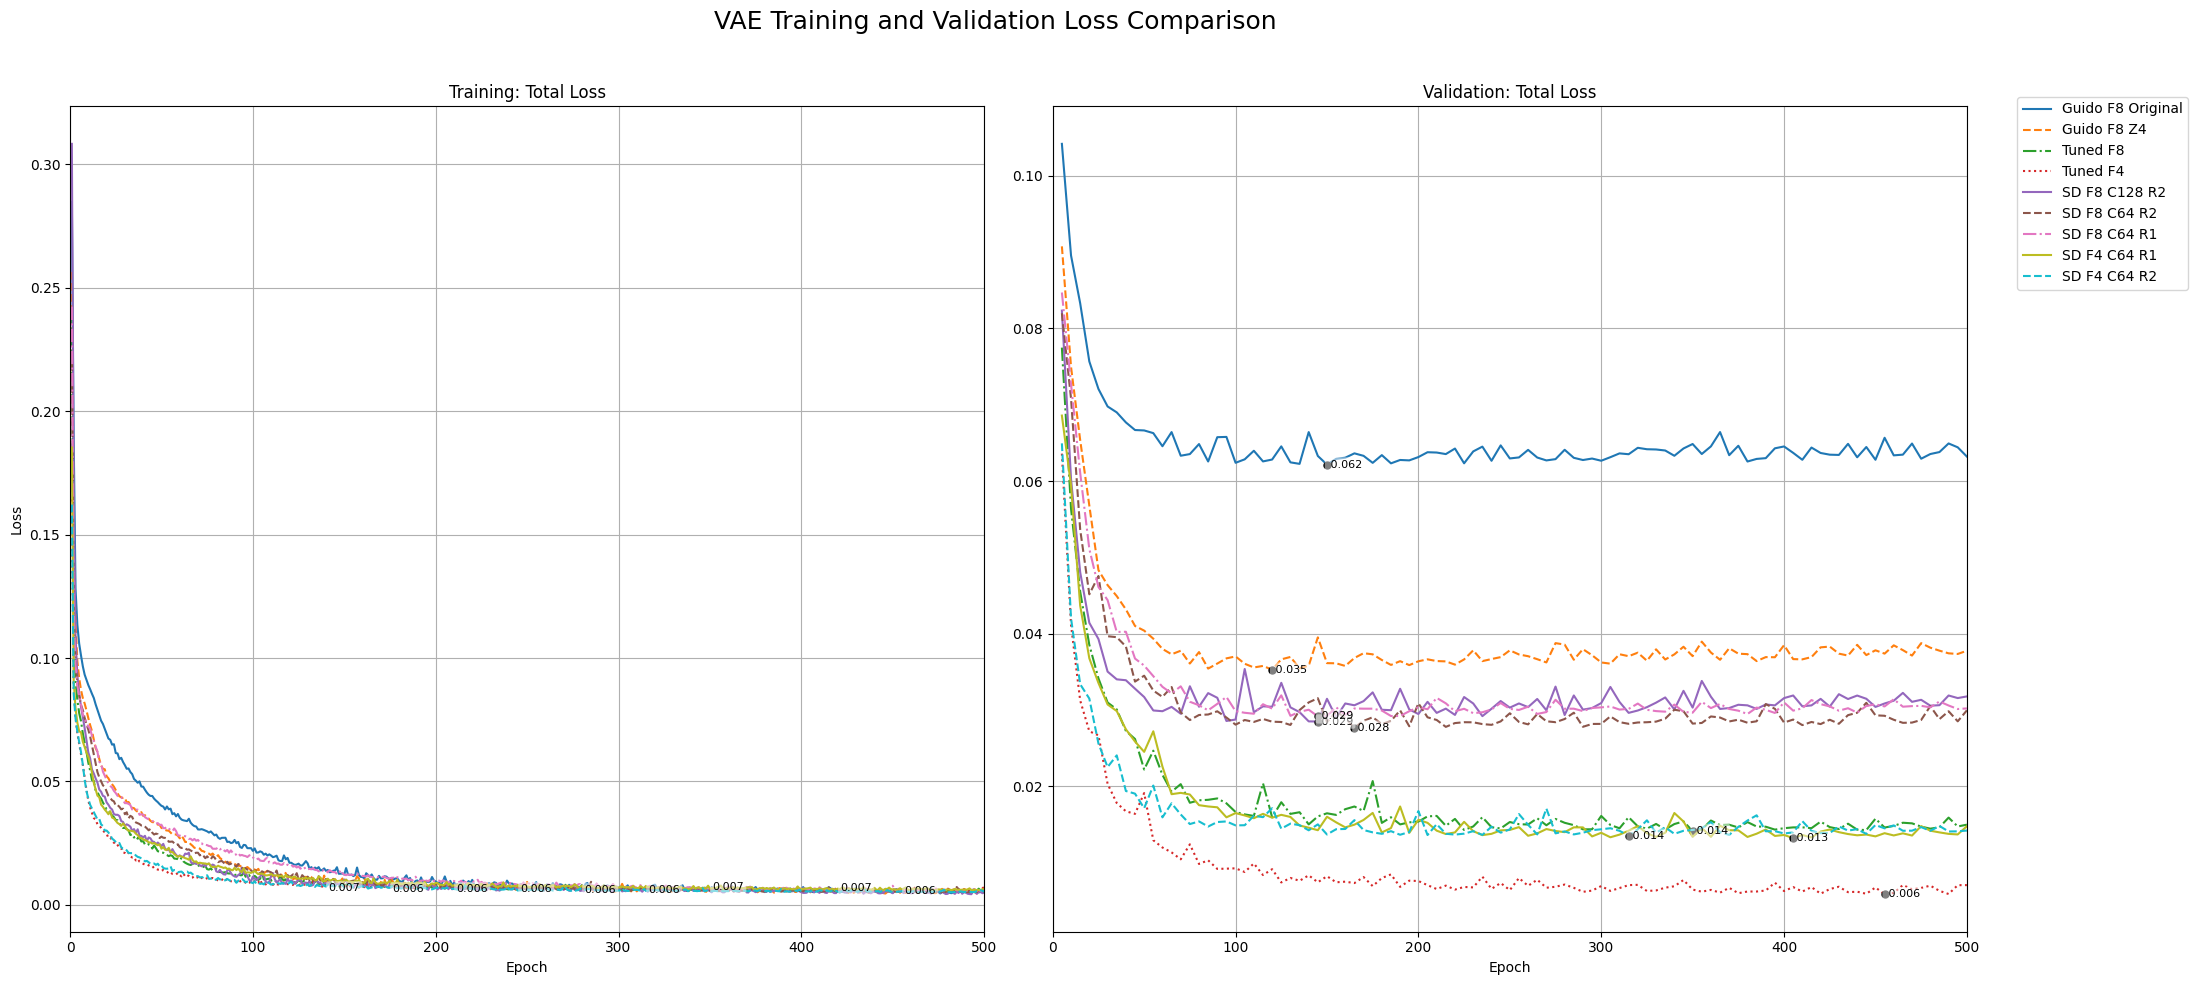

In [17]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
model_names = [
                "Guido F8 Original",
                "Guido F8 Z4",
                "Tuned F8",
                "Tuned F4",
                "SD F8 C128 R2",
                "SD F8 C64 R2",
                "SD F8 C64 R1",
                "SD F4 C128 R2",
                "SD F4 C64 R1",
                "SD F4 C64 R2"
               ]
# --- Configuration ---
# Path to your training log file
log_file_paths = [
    r"E:\Code\monai\ldm_2d_geomodel\logs\guido_f8_original_vae_training_log_epochs500_hd0.json", # Guido F8 Original
    r"E:\Code\monai\ldm_2d_geomodel\logs\guido_f8_z4_vae_training_log_epochs500_hd0.json", # Guido F8 Z4
    r"E:\Code\monai\ldm_2d_geomodel\logs\tuned_f8_vae_training_log_epochs500_hd0.json", # Tuned F8
    r"E:\Code\monai\ldm_2d_geomodel\logs\tuned_f4_vae_training_log_epochs500_hd0.json", # Tuned F4
    r"E:\Code\monai\ldm_2d_geomodel\logs\SD_f8_c128_r2_vae_training_log_epochs500_hd0.json", # SD F8 C128 R2
    r"E:\Code\monai\ldm_2d_geomodel\logs\SD_f8_c64_r2_vae_training_log_epochs500_hd0.json", # SD F8 C64 R2
    r"E:\Code\monai\ldm_2d_geomodel\logs\SD_f8_c64_r1_vae_training_log_epochs500_hd0.json", # SD F8 C64 R1
    r"E:\Code\monai\ldm_2d_geomodel\logs\SD_f4_c128_r2_vae_training_log_epochs1000_hd0.json", # SD F4 C128 R2
    r"E:\Code\monai\ldm_2d_geomodel\logs\SD_f4_c64_r1_vae_training_log_epochs500_hd0.json", # SD F4 C64 R1
    r"E:\Code\monai\ldm_2d_geomodel\logs\SD_f4_c64_r2_vae_training_log_epochs500_hd0.json" # SD F4 C64 R2
    ]

# Define the keys for the losses you want to plot
train_loss_keys = ['epoch_losses']
val_loss_keys = ['val_losses']
plot_titles = ['Total Loss']

# Create a 2x2 grid of subplots for better layout
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=True)
fig.suptitle('VAE Training and Validation Loss Comparison', fontsize=18)

# Define a set of distinct colors and line styles
colors = plt.get_cmap('tab10').colors
linestyles = ['-', '--', '-.', ':']

# --- Plot All Models ---
for i, (log_path, model_name) in enumerate(zip(log_file_paths, model_names)):
    if not os.path.exists(log_path):
        print(f"Warning: Log file not found for {model_name} at {log_path}")
        continue

    with open(log_path, "r") as f:
        log = json.load(f)

    val_interval = args.autoencoder_train["val_interval"]
    
    # Assign a unique color and line style to each model
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]

    # --- Plot Training Losses ---
    annotation_interval = (500-150)//len(log_file_paths)
    for j, key in enumerate(train_loss_keys):
        if key in log:
            loss_values = np.array(log[key])
            epochs = np.arange(1, len(loss_values) + 1)
            ax = axes[0]
            ax.plot(epochs, loss_values, label=f"{model_name}", color=color, linestyle=linestyle)
            ax.set_title(f'Training: {plot_titles[j]}')
            ax.set_ylabel('Loss')
            ax.grid(True)
            ax.set_xlim([0,500])

            # Add annotation for mean and std after epoch 150
            if len(epochs) > 200:
                mean_loss = np.mean(loss_values[200:])
                # std_loss = np.std(loss_values[200:])
                ax.text(150+annotation_interval*i, mean_loss, 
                        # f'{mean_loss:.3f} ± {std_loss:.3f}', 
                        f'{mean_loss:.3f}',
                        color='black', fontsize=8, verticalalignment='center', horizontalalignment='center',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

    # --- Plot Validation Losses ---
    for j, key in enumerate(val_loss_keys):
        if key in log:
            loss_values = np.array(log[key])
            epochs = np.arange(1, len(loss_values) + 1) * val_interval
            ax = axes[1]
            ax.plot(epochs, loss_values, label=f"{model_name}", color=color, linestyle=linestyle)
            ax.set_title(f'Validation: {plot_titles[j]}')
            ax.grid(True)

            # Add annotation for mean and std after epoch 150
            post_200_mask = epochs > 200
            # Add annotation for best (minimum) validation loss
            if len(loss_values) > 0:
                best_loss_idx = np.argmin(loss_values)
                best_loss = loss_values[best_loss_idx]
                best_loss_epoch = epochs[best_loss_idx]
                
                ax.plot(best_loss_epoch, best_loss, 'o', color='black', markersize=5)
                ax.text(best_loss_epoch, best_loss, f' {best_loss:.3f}', 
                        color='black', fontsize=8, verticalalignment='center',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))


# Add x-axis labels to the bottom plots
axes[0].set_xlabel('Epoch')
axes[1].set_xlabel('Epoch')

# Create a single legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 0.9))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()